In [ ]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

import zipfile
import os
import pandas as pd
import numpy as np
import glob
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import re

# Set plot style - using available styles
# Check available styles first
print("Available styles:", plt.style.available[:5])  # Show first 5

# Use a style that exists
try:
    plt.style.use('seaborn-v0_8-whitegrid')  # Updated style name
except:
    try:
        plt.style.use('seaborn-whitegrid')  # Alternative
    except:
        plt.style.use('ggplot')  # Fallback

plt.rcParams['figure.figsize'] = (12, 6)

print("✓ Libraries imported successfully!")

Available styles: ['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh']
✓ Libraries imported successfully!


**Define Function to Load Sensor Logger CSV**

In [ ]:
# ============================================
# CELL 2: LOAD AND PARSE CSV FILES
# ============================================

def load_sensor_data_from_zip(zip_path, sensor_name):
    """
    Load sensor data from ZIP file.
    Handles format: date,"timestamp,value"
    """
    # Create extraction folder
    extract_folder = f'/content/{sensor_name}_extracted'
    os.makedirs(extract_folder, exist_ok=True)

    # Extract ZIP
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_folder)

    # Find all CSV files
    csv_files = sorted(glob.glob(os.path.join(extract_folder, '*.csv')))
    print(f"Found {len(csv_files)} CSV files for {sensor_name}")

    all_data = []

    for csv_file in csv_files:
        print(f"  Reading: {os.path.basename(csv_file)}")

        with open(csv_file, 'r') as f:
            lines = f.readlines()

        # Parse each line
        for line in lines:
            line = line.strip()
            if not line:
                continue

            try:
                # Format: 2026/07/04,"11:32:03.196,-0.139603"
                # Split by comma
                parts = line.split(',')

                if len(parts) >= 3:
                    # Extract timestamp (remove quotes)
                    timestamp_str = parts[1].strip('"')
                    # Extract value (remove quotes)
                    value_str = parts[2].strip('"')
                    value = float(value_str)

                    # Store timestamp and value
                    all_data.append({
                        'timestamp_raw': timestamp_str,
                        'value': value
                    })
            except Exception as e:
                # Skip lines that can't be parsed
                continue

    # Convert to DataFrame
    df = pd.DataFrame(all_data)

    if not df.empty:
        # Parse timestamps to seconds
        df['time_seconds'] = df['timestamp_raw'].apply(parse_timestamp)
        df = df.dropna(subset=['time_seconds'])

        # Sort by time
        df = df.sort_values('time_seconds').reset_index(drop=True)

    print(f"  Loaded {len(df)} valid samples")
    return df

def parse_timestamp(timestamp_str):
    """
    Convert 'HH:MM:SS.mmm' to total seconds.
    """
    try:
        # Clean the timestamp string
        timestamp_str = timestamp_str.strip()

        # Split into hours, minutes, seconds
        time_parts = timestamp_str.split(':')
        hours = int(time_parts[0])
        minutes = int(time_parts[1])

        # Handle seconds with milliseconds
        sec_parts = time_parts[2].split('.')
        seconds = int(sec_parts[0])
        milliseconds = int(sec_parts[1]) if len(sec_parts) > 1 else 0

        # Convert to total seconds
        total_seconds = hours * 3600 + minutes * 60 + seconds + milliseconds / 1000.0
        return total_seconds
    except:
        return None

def extract_zip_files():
    """Extract accelerometer and gyroscope ZIP files."""

    # Extract accelerometer
    accel_zip = '/content/accelersensorlog (1).zip'
    if os.path.exists(accel_zip):
        print(f"✓ Found accelerometer ZIP: {accel_zip}")
        accel_df = load_sensor_data_from_zip(accel_zip, 'accel')
    else:
        print(f"✗ File not found: {accel_zip}")
        accel_df = pd.DataFrame()

    # Extract gyroscope
    gyro_zip = '//content/gyrologs (1).zip'
    if os.path.exists(gyro_zip):
        print(f"✓ Found gyroscope ZIP: {gyro_zip}")
        gyro_df = load_sensor_data_from_zip(gyro_zip, 'gyro')
    else:
        print(f"✗ File not found: {gyro_zip}")
        gyro_df = pd.DataFrame()

    return accel_df, gyro_df

print("✓ Data loading functions defined!")

✓ Data loading functions defined!


**Define Function to Extract and Combine ZIP Files**

In [ ]:
# ============================================
# CELL 3: LOAD AND EXTRACT DATA
# ============================================

print("\n" + "=" * 60)
print("LOADING SENSOR DATA")
print("=" * 60)

accel_df, gyro_df = extract_zip_files()

print("\n" + "-" * 40)
print("DATA SUMMARY")
print("-" * 40)
print(f"Accelerometer samples: {len(accel_df)}")
print(f"Gyroscope samples: {len(gyro_df)}")

if not accel_df.empty:
    print("\nAccelerometer first 5 rows:")
    print(accel_df.head())
    print(f"\nAccel time range: {accel_df['time_seconds'].min():.2f} to {accel_df['time_seconds'].max():.2f} seconds")

if not gyro_df.empty:
    print("\nGyroscope first 5 rows:")
    print(gyro_df.head())
    print(f"\nGyro time range: {gyro_df['time_seconds'].min():.2f} to {gyro_df['time_seconds'].max():.2f} seconds")


LOADING SENSOR DATA
✓ Found accelerometer ZIP: /content/accelersensorlog (1).zip
Found 3 CSV files for accel
  Reading: accelersensorlog-1.csv
  Reading: accelersensorlog-2.csv
  Reading: accelersensorlog.csv
  Loaded 1146 valid samples
✓ Found gyroscope ZIP: //content/gyrologs (1).zip
Found 3 CSV files for gyro
  Reading: gyrologs-1.csv
  Reading: gyrologs-2.csv
  Reading: gyrologs.csv
  Loaded 795 valid samples

----------------------------------------
DATA SUMMARY
----------------------------------------
Accelerometer samples: 1146
Gyroscope samples: 795

Accelerometer first 5 rows:
  timestamp_raw     value  time_seconds
0  11:32:03.196 -0.649734     41523.196
1  11:32:03.196 -0.139603     41523.196
2  11:32:03.196 -0.737045     41523.196
3  11:32:03.265 -0.647842     41523.265
4  11:32:03.265 -0.132217     41523.265

Accel time range: 41523.20 to 41561.16 seconds

Gyroscope first 5 rows:
  timestamp_raw     value  time_seconds
0  11:39:57.722 -0.591400     41997.722
1  11:39:57.7

**Define Function to Parse Timestamps**

In [ ]:
# ============================================
# CELL 4: RESHAPE DATA TO REGULAR TIME SERIES
# ============================================

def reshape_to_regular_timeseries(df, target_rate=50):
    """
    Reshape timestamp-value pairs into a regular time series.
    """
    if df.empty:
        return pd.DataFrame()

    # Get time range
    start_time = df['time_seconds'].min()
    end_time = df['time_seconds'].max()

    # Create regular time grid
    duration = end_time - start_time
    num_samples = int(duration * target_rate)

    if num_samples == 0:
        return pd.DataFrame()

    new_times = np.linspace(start_time, end_time, num_samples)

    # Interpolate values onto regular grid
    f = interp1d(
        df['time_seconds'],
        df['value'],
        kind='linear',
        fill_value='extrapolate'
    )
    interpolated_values = f(new_times)

    # Create DataFrame with regular sampling
    reshaped_df = pd.DataFrame({
        'timestamp': new_times,
        'value': interpolated_values
    })

    return reshaped_df

print("\n" + "=" * 60)
print("RESHAPING DATA")
print("=" * 60)

TARGET_RATE = 50  # Hz

# Reshape both datasets
if not accel_df.empty:
    accel_reshaped = reshape_to_regular_timeseries(accel_df, TARGET_RATE)
    print(f"✓ Accelerometer reshaped: {len(accel_reshaped)} samples at {TARGET_RATE} Hz")
else:
    accel_reshaped = pd.DataFrame()
    print("✗ Accelerometer data empty, cannot reshape")

if not gyro_df.empty:
    gyro_reshaped = reshape_to_regular_timeseries(gyro_df, TARGET_RATE)
    print(f"✓ Gyroscope reshaped: {len(gyro_reshaped)} samples at {TARGET_RATE} Hz")
else:
    gyro_reshaped = pd.DataFrame()
    print("✗ Gyroscope data empty, cannot reshape")

# Show first few samples
if not accel_reshaped.empty:
    print("\nAccelerometer reshaped (first 10 samples):")
    print(accel_reshaped.head(10))

if not gyro_reshaped.empty:
    print("\nGyroscope reshaped (first 10 samples):")
    print(gyro_reshaped.head(10))


RESHAPING DATA
✓ Accelerometer reshaped: 1898 samples at 50 Hz
✓ Gyroscope reshaped: 1318 samples at 50 Hz

Accelerometer reshaped (first 10 samples):
      timestamp     value
0  41523.196000       NaN
1  41523.216015 -0.711170
2  41523.236030 -0.685295
3  41523.256044 -0.659420
4  41523.276059 -0.747283
5  41523.296074 -0.721709
6  41523.316089 -0.696134
7  41523.336103 -0.670560
8  41523.356118 -0.644985
9  41523.376133 -0.781357

Gyroscope reshaped (first 10 samples):
      timestamp     value
0  41997.722000       NaN
1  41997.742029 -0.508218
2  41997.762058 -0.365954
3  41997.782087 -0.223690
4  41997.802115 -0.081425
5  41997.822144 -0.601023
6  41997.842173 -0.595992
7  41997.862202 -0.590962
8  41997.882231 -0.585931
9  41997.902260 -0.580901


/usr/local/lib/python3.12/dist-packages/scipy/interpolate/_interpolate.py:497: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/usr/local/lib/python3.12/dist-packages/scipy/interpolate/_interpolate.py:500: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


In [ ]:
# ============================================
# CELL 5: MERGE ACCELEROMETER AND GYROSCOPE
# ============================================

print("\n" + "=" * 60)
print("MERGING SENSOR DATA")
print("=" * 60)

# Check if both DataFrames exist and are not empty
if not accel_reshaped.empty and not gyro_reshaped.empty:

    # Find the minimum length
    min_len = min(len(accel_reshaped), len(gyro_reshaped))

    # Create merged DataFrame with aligned timestamps
    merged_df = pd.DataFrame({
        'timestamp': accel_reshaped['timestamp'][:min_len],
        'accel': accel_reshaped['value'][:min_len],
        'gyro': gyro_reshaped['value'][:min_len]
    })

    print(f"✓ Merged {min_len} samples")
    print("\nMerged data columns:", merged_df.columns.tolist())
    print("\nFirst 10 rows:")
    print(merged_df.head(10))
    print(f"\nTime range: {merged_df['timestamp'].min():.2f} to {merged_df['timestamp'].max():.2f} seconds")

else:
    print("✗ Cannot merge: One or both datasets are empty")
    merged_df = pd.DataFrame()


MERGING SENSOR DATA
✓ Merged 1318 samples

Merged data columns: ['timestamp', 'accel', 'gyro']

First 10 rows:
      timestamp     accel      gyro
0  41523.196000       NaN       NaN
1  41523.216015 -0.711170 -0.508218
2  41523.236030 -0.685295 -0.365954
3  41523.256044 -0.659420 -0.223690
4  41523.276059 -0.747283 -0.081425
5  41523.296074 -0.721709 -0.601023
6  41523.316089 -0.696134 -0.595992
7  41523.336103 -0.670560 -0.590962
8  41523.356118 -0.644985 -0.585931
9  41523.376133 -0.781357 -0.580901

Time range: 41523.20 to 41549.56 seconds



VISUALIZING DATA
Actual sampling rate: 49.96 Hz
Number of samples: 1318
Duration: 26.36 seconds


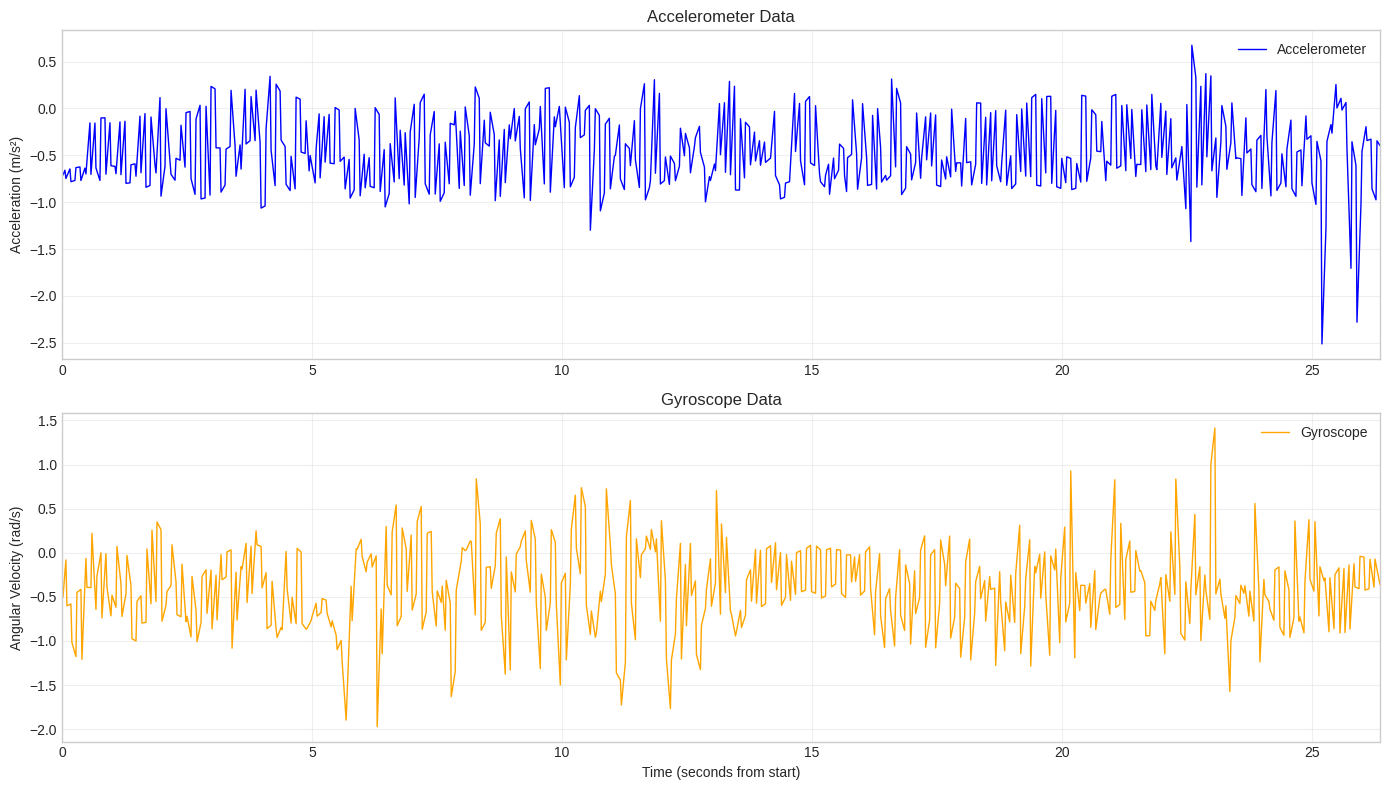

In [ ]:
# ============================================
# CELL 6: VISUALIZE DATA
# ============================================

if not merged_df.empty:
    print("\n" + "=" * 60)
    print("VISUALIZING DATA")
    print("=" * 60)

    # Calculate actual sampling rate
    time_diffs = merged_df['timestamp'].diff()
    avg_diff = time_diffs.mean()
    actual_rate = 1.0 / avg_diff if avg_diff > 0 else 0

    print(f"Actual sampling rate: {actual_rate:.2f} Hz")
    print(f"Number of samples: {len(merged_df)}")
    print(f"Duration: {merged_df['timestamp'].iloc[-1] - merged_df['timestamp'].iloc[0]:.2f} seconds")

    # Create plots
    fig, axes = plt.subplots(2, 1, figsize=(14, 8))

    time_rel = merged_df['timestamp'] - merged_df['timestamp'].iloc[0]

    # Accelerometer
    axes[0].plot(time_rel, merged_df['accel'], label='Accelerometer', linewidth=1, color='blue')
    axes[0].set_ylabel('Acceleration (m/s²)')
    axes[0].set_title('Accelerometer Data')
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()
    axes[0].set_xlim([0, time_rel.iloc[-1]])

    # Gyroscope
    axes[1].plot(time_rel, merged_df['gyro'], label='Gyroscope', linewidth=1, color='orange')
    axes[1].set_ylabel('Angular Velocity (rad/s)')
    axes[1].set_xlabel('Time (seconds from start)')
    axes[1].set_title('Gyroscope Data')
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()
    axes[1].set_xlim([0, time_rel.iloc[-1]])

    plt.tight_layout()
    plt.show()

else:
    print("✗ No data to visualize")

In [ ]:
# ============================================
# CELL 7: SAVE PROCESSED DATA
# ============================================

if not merged_df.empty:
    print("\n" + "=" * 60)
    print("SAVING DATA")
    print("=" * 60)

    # Save merged data
    merged_df.to_csv('/content/processed_sensor_data.csv', index=False)
    print("✓ Saved: processed_sensor_data.csv")

    # Save metadata
    with open('/content/data_metadata.txt', 'w') as f:
        f.write("PROCESSED SENSOR DATA METADATA\n")
        f.write("=" * 40 + "\n\n")
        f.write(f"Number of samples: {len(merged_df)}\n")
        f.write(f"Sampling rate: {actual_rate:.2f} Hz\n")
        f.write(f"Duration: {merged_df['timestamp'].iloc[-1] - merged_df['timestamp'].iloc[0]:.2f} seconds\n")
        f.write(f"Columns: {merged_df.columns.tolist()}\n")
        f.write(f"\nAccelerometer stats:\n")
        f.write(f"  Mean: {merged_df['accel'].mean():.4f}\n")
        f.write(f"  Std: {merged_df['accel'].std():.4f}\n")
        f.write(f"  Min: {merged_df['accel'].min():.4f}\n")
        f.write(f"  Max: {merged_df['accel'].max():.4f}\n")
        f.write(f"\nGyroscope stats:\n")
        f.write(f"  Mean: {merged_df['gyro'].mean():.4f}\n")
        f.write(f"  Std: {merged_df['gyro'].std():.4f}\n")
        f.write(f"  Min: {merged_df['gyro'].min():.4f}\n")
        f.write(f"  Max: {merged_df['gyro'].max():.4f}\n")

    print("✓ Saved: data_metadata.txt")

    print("\n" + "=" * 60)
    print("DATA PROCESSING COMPLETE!")
    print("=" * 60)

else:
    print("✗ No data to save")


SAVING DATA
✓ Saved: processed_sensor_data.csv
✓ Saved: data_metadata.txt

DATA PROCESSING COMPLETE!


In [ ]:
# ============================================
# CELL 9: LOAD PROCESSED DATA
# ============================================

print("=" * 60)
print("LOADING PROCESSED DATA")
print("=" * 60)

# Load the processed data
merged_df = pd.read_csv('/content/processed_sensor_data.csv')
print(f"✓ Loaded {len(merged_df)} samples")
print("\nFirst 5 rows:")
print(merged_df.head())

# Load metadata
with open('/content/data_metadata.txt', 'r') as f:
    print("\n" + f.read())

# Data statistics
print("\nData Statistics:")
print(merged_df.describe())

LOADING PROCESSED DATA
✓ Loaded 1318 samples

First 5 rows:
      timestamp     accel      gyro
0  41523.196000       NaN       NaN
1  41523.216015 -0.711170 -0.508218
2  41523.236030 -0.685295 -0.365954
3  41523.256044 -0.659420 -0.223690
4  41523.276059 -0.747283 -0.081425

PROCESSED SENSOR DATA METADATA

Number of samples: 1318
Sampling rate: 49.96 Hz
Duration: 26.36 seconds
Columns: ['timestamp', 'accel', 'gyro']

Accelerometer stats:
  Mean: -0.4566
  Std: 0.3523
  Min: -2.5120
  Max: 0.6738

Gyroscope stats:
  Mean: -0.4066
  Std: 0.4371
  Min: -1.9720
  Max: 1.4147


Data Statistics:
          timestamp        accel         gyro
count   1318.000000  1317.000000  1317.000000
mean   41536.375720    -0.456640    -0.406623
std        7.617981     0.352330     0.437074
min    41523.196000    -2.512035    -1.971985
25%    41529.785860    -0.717363    -0.708829
50%    41536.375720    -0.490516    -0.416233
75%    41542.965579    -0.199970    -0.112604
max    41549.555439     0.673762  

In [ ]:
# ============================================
# CELL 10: DEFINE WINDOW PARAMETERS
# ============================================

print("=" * 60)
print("DEFINING WINDOW PARAMETERS")
print("=" * 60)

# Sampling rate from your data
SAMPLING_RATE = 50  # Hz (based on our resampling)

# Window parameters - choose one:
WINDOW_DURATION = 2.5  # seconds (captures gait cycle for walking)

# Calculate window sizes
WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_DURATION)  # samples per window
STEP_SIZE = int(WINDOW_SIZE / 2)  # 50% overlap

print(f"Sampling rate: {SAMPLING_RATE} Hz")
print(f"Window duration: {WINDOW_DURATION} seconds")
print(f"Window size: {WINDOW_SIZE} samples")
print(f"Step size: {STEP_SIZE} samples")
print(f"Overlap: {((WINDOW_SIZE - STEP_SIZE) / WINDOW_SIZE * 100):.0f}%")

# Justification for report
print("\n📝 Justification for window size:")
print(f"• {WINDOW_DURATION}-second window captures approximately one full gait cycle")
print("• This provides enough data for both time-domain and frequency-domain analysis")
print("• 50% overlap ensures we don't miss transitions between activities")

DEFINING WINDOW PARAMETERS
Sampling rate: 50 Hz
Window duration: 2.5 seconds
Window size: 125 samples
Step size: 62 samples
Overlap: 50%

📝 Justification for window size:
• 2.5-second window captures approximately one full gait cycle
• This provides enough data for both time-domain and frequency-domain analysis
• 50% overlap ensures we don't miss transitions between activities


In [ ]:
# ============================================
# CELL 11: FEATURE EXTRACTION (REDUCED FEATURES)
# ============================================

print("=" * 60)
print("EXTRACTING FEATURES (REDUCED)")
print("=" * 60)

def create_windows_and_extract_features(df, window_size, step_size):
    """
    Create sliding windows and extract features from each window.
    Using fewer features to avoid overfitting.
    """
    features_list = []

    # Get the data
    accel_data = df['accel'].values
    gyro_data = df['gyro'].values

    total_samples = len(df)
    num_windows = (total_samples - window_size) // step_size + 1

    print(f"Creating {num_windows} windows...")

    for i in range(num_windows):
        start = i * step_size
        end = start + window_size

        # Get window data
        accel_window = accel_data[start:end]
        gyro_window = gyro_data[start:end]

        # Extract features
        features = {}

        # --- TIME-DOMAIN FEATURES (Reduced set) ---

        # Mean
        features['accel_mean'] = np.mean(accel_window)
        features['gyro_mean'] = np.mean(gyro_window)

        # Standard deviation
        features['accel_std'] = np.std(accel_window)
        features['gyro_std'] = np.std(gyro_window)

        # RMS (Root Mean Square)
        features['accel_rms'] = np.sqrt(np.mean(accel_window**2))
        features['gyro_rms'] = np.sqrt(np.mean(gyro_window**2))

        # Signal Magnitude Area (SMA)
        features['accel_sma'] = np.sum(np.abs(accel_window)) / window_size
        features['gyro_sma'] = np.sum(np.abs(gyro_window)) / window_size

        # --- FREQUENCY-DOMAIN FEATURES (Reduced set) ---

        # Compute FFT for accelerometer
        n = len(accel_window)
        fft_vals = np.fft.fft(accel_window - np.mean(accel_window))
        fft_freq = np.fft.fftfreq(n, 1/SAMPLING_RATE)

        # Only keep positive frequencies
        positive_idx = fft_freq > 0
        fft_magnitude = np.abs(fft_vals[positive_idx])
        fft_freq_pos = fft_freq[positive_idx]

        # Dominant frequency (only for accel)
        if len(fft_magnitude) > 0 and np.max(fft_magnitude) > 1e-10:
            dominant_idx = np.argmax(fft_magnitude)
            features['accel_dominant_freq'] = fft_freq_pos[dominant_idx]
            features['accel_dominant_mag'] = fft_magnitude[dominant_idx]
        else:
            features['accel_dominant_freq'] = 0.0
            features['accel_dominant_mag'] = 0.0

        # Spectral energy (only for accel)
        features['accel_spectral_energy'] = np.sum(fft_magnitude**2)

        # Dominant frequency for gyroscope (only if data has variation)
        fft_vals_gyro = np.fft.fft(gyro_window - np.mean(gyro_window))
        fft_magnitude_gyro = np.abs(fft_vals_gyro[positive_idx])

        if len(fft_magnitude_gyro) > 0 and np.max(fft_magnitude_gyro) > 1e-10:
            dominant_idx_gyro = np.argmax(fft_magnitude_gyro)
            features['gyro_dominant_freq'] = fft_freq_pos[dominant_idx_gyro]
            features['gyro_dominant_mag'] = fft_magnitude_gyro[dominant_idx_gyro]
        else:
            features['gyro_dominant_freq'] = 0.0
            features['gyro_dominant_mag'] = 0.0

        # Spectral energy for gyroscope
        features['gyro_spectral_energy'] = np.sum(fft_magnitude_gyro**2)

        features_list.append(features)

    return pd.DataFrame(features_list)

# Use a larger window to get more samples per window
# This reduces the number of windows but gives more data per window
WINDOW_DURATION = 2.0  # 2 seconds
WINDOW_SIZE = int(SAMPLING_RATE * WINDOW_DURATION)
STEP_SIZE = int(WINDOW_SIZE / 2)  # 50% overlap

print(f"Updated window settings:")
print(f"  Window duration: {WINDOW_DURATION} seconds")
print(f"  Window size: {WINDOW_SIZE} samples")
print(f"  Step size: {STEP_SIZE} samples")

# Extract features
features_df = create_windows_and_extract_features(merged_df, WINDOW_SIZE, STEP_SIZE)
print(f"\n✓ Extracted features from {len(features_df)} windows")

# Check for NaN values
nan_count = features_df.isna().sum().sum()
if nan_count > 0:
    print(f"⚠️  Found {nan_count} NaN values. Replacing with 0...")
    features_df = features_df.fillna(0)

print(f"\nFeature columns ({len(features_df.columns)} features):")
print(features_df.columns.tolist())

print("\nFirst 5 rows of features:")
print(features_df.head())

EXTRACTING FEATURES (REDUCED)
Updated window settings:
  Window duration: 2.0 seconds
  Window size: 100 samples
  Step size: 50 samples
Creating 25 windows...

✓ Extracted features from 25 windows
⚠️  Found 10 NaN values. Replacing with 0...

Feature columns (14 features):
['accel_mean', 'gyro_mean', 'accel_std', 'gyro_std', 'accel_rms', 'gyro_rms', 'accel_sma', 'gyro_sma', 'accel_dominant_freq', 'accel_dominant_mag', 'accel_spectral_energy', 'gyro_dominant_freq', 'gyro_dominant_mag', 'gyro_spectral_energy']

First 5 rows of features:
   accel_mean  gyro_mean  accel_std  gyro_std  accel_rms  gyro_rms  accel_sma  \
0    0.000000   0.000000   0.000000  0.000000   0.000000  0.000000   0.000000   
1   -0.498730  -0.457529   0.305166  0.335514   0.584687  0.567364   0.506855   
2   -0.399529  -0.394768   0.347757  0.317020   0.529678  0.506303   0.439394   
3   -0.357479  -0.429887   0.371623  0.348433   0.515650  0.553361   0.436900   
4   -0.436952  -0.666058   0.358319  0.395313   0.565

In [ ]:
# ============================================
# CELL 12: NORMALIZE FEATURES
# ============================================

print("=" * 60)
print("NORMALIZING FEATURES")
print("=" * 60)

from sklearn.preprocessing import StandardScaler

# Create feature matrix
feature_columns = features_df.columns.tolist()
X = features_df[feature_columns].values

# Replace any NaN or Inf with 0
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Data shape: {X.shape}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")

# Apply Z-score normalization
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Convert back to DataFrame
features_normalized_df = pd.DataFrame(
    X_normalized,
    columns=feature_columns
)

print("✓ Features normalized using Z-score standardization")
print(f"\nNormalized features shape: {features_normalized_df.shape}")

# Save normalized features
features_normalized_df.to_csv('/content/normalized_features.csv', index=False)
print("\n✓ Normalized features saved to 'normalized_features.csv'")

# Save the scaler
import joblib
joblib.dump(scaler, '/content/feature_scaler.pkl')
print("✓ Feature scaler saved to 'feature_scaler.pkl'")

NORMALIZING FEATURES
Data shape: (25, 14)
Number of features: 14
Number of samples: 25
✓ Features normalized using Z-score standardization

Normalized features shape: (25, 14)

✓ Normalized features saved to 'normalized_features.csv'
✓ Feature scaler saved to 'feature_scaler.pkl'


VISUALIZING FEATURES


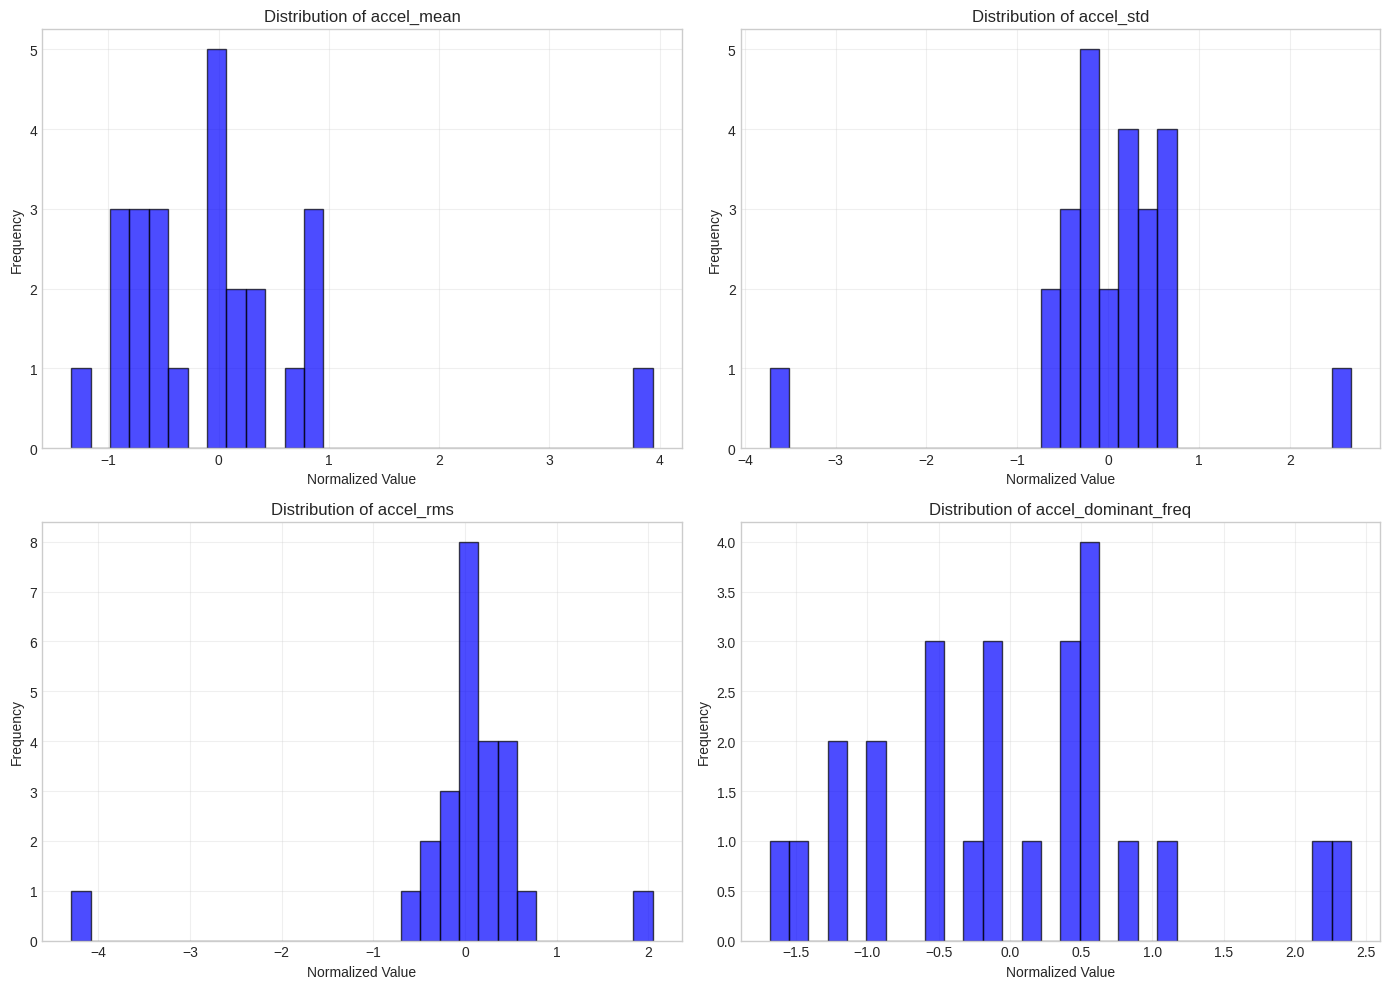


Feature Correlation Matrix:


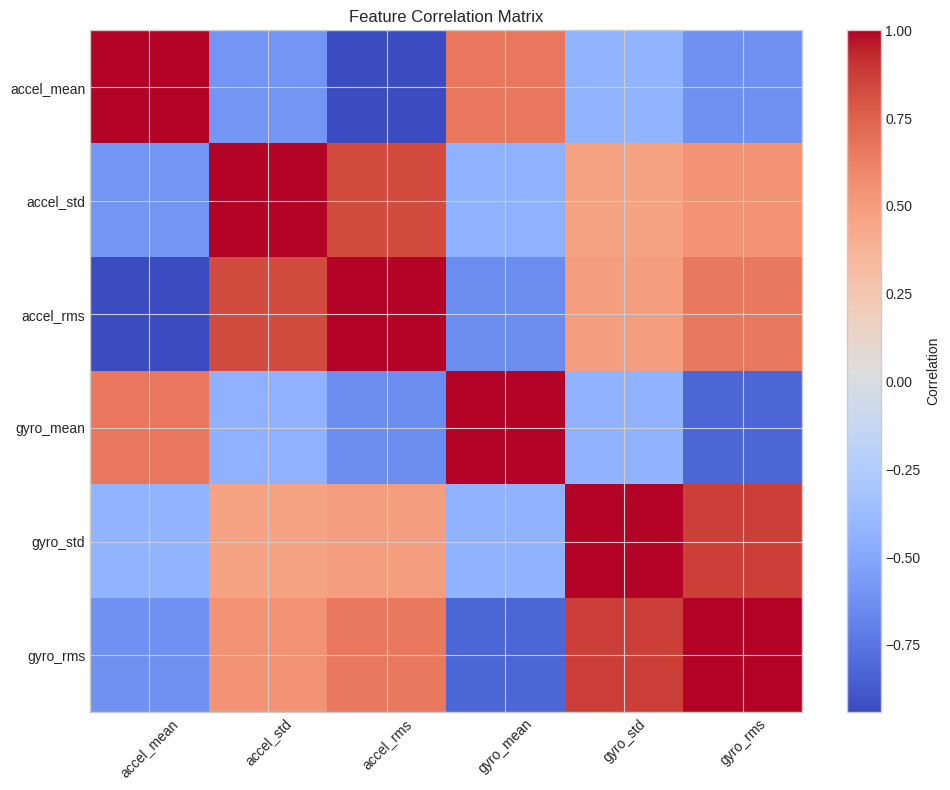

In [ ]:
# ============================================
# CELL 13: VISUALIZE FEATURES
# ============================================

print("=" * 60)
print("VISUALIZING FEATURES")
print("=" * 60)

# Select key features to visualize
key_features = ['accel_mean', 'accel_std', 'accel_rms', 'accel_dominant_freq']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(key_features):
    if i < len(axes):
        axes[i].hist(features_normalized_df[feature], bins=30, alpha=0.7, color='blue', edgecolor='black')
        axes[i].set_title(f'Distribution of {feature}')
        axes[i].set_xlabel('Normalized Value')
        axes[i].set_ylabel('Frequency')
        axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Feature correlation heatmap
print("\nFeature Correlation Matrix:")
selected_features = ['accel_mean', 'accel_std', 'accel_rms', 'gyro_mean', 'gyro_std', 'gyro_rms']
corr_matrix = features_normalized_df[selected_features].corr()

plt.figure(figsize=(10, 8))
plt.imshow(corr_matrix, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Correlation')
plt.xticks(range(len(selected_features)), selected_features, rotation=45)
plt.yticks(range(len(selected_features)), selected_features)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 14: PREPARE FOR HMM TRAINING
# ============================================

print("=" * 60)
print("PREPARING FOR HMM TRAINING")
print("=" * 60)

# Number of hidden states (4 activities)
N_STATES = 4

# Convert features to numpy array for HMM
observation_sequences = features_normalized_df.values

print(f"Number of observations: {len(observation_sequences)}")
print(f"Number of features per observation: {observation_sequences.shape[1]}")
print(f"Number of hidden states: {N_STATES}")

print("\n📝 HMM Configuration:")
print(f"  • States: Standing, Walking, Jumping, Still")
print(f"  • Observations: {observation_sequences.shape[1]} feature vectors")
print(f"  • Training samples: {len(observation_sequences)}")

# Save observations for HMM
np.save('/content/hmm_observations.npy', observation_sequences)
print("\n✓ Observations saved to 'hmm_observations.npy'")

print("\n✅ Ready for HMM Training!")
print("Next step: Implement the HMM using hmmlearn library")


PREPARING FOR HMM TRAINING
Number of observations: 25
Number of features per observation: 14
Number of hidden states: 4

📝 HMM Configuration:
  • States: Standing, Walking, Jumping, Still
  • Observations: 14 feature vectors
  • Training samples: 25

✓ Observations saved to 'hmm_observations.npy'

✅ Ready for HMM Training!
Next step: Implement the HMM using hmmlearn library


In [ ]:
# ============================================
# CELL 15: INSTALL hmmlearn
# ============================================

print("=" * 60)
print("INSTALLING hmmlearn")
print("=" * 60)

!pip install hmmlearn -q

from hmmlearn import hmm
import numpy as np

print("✓ hmmlearn installed and imported successfully!")

# Check version using different method
try:
    import pkg_resources
    version = pkg_resources.get_distribution("hmmlearn").version
    print(f"Version: {version}")
except:
    print("Version check skipped (not required)")

print("\n✓ Ready for HMM training!")

INSTALLING hmmlearn
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 3.1 MB/s eta 0:00:00
✓ hmmlearn installed and imported successfully!
Version: 0.3.3

✓ Ready for HMM training!


/tmp/ipykernel_7698/583371108.py:18: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [ ]:
# ============================================
# CELL 16b: TRAIN HMM WITH 4 STATES (ALTERNATIVE)
# ============================================

print("=" * 60)
print("TRAINING HMM WITH 4 STATES (FORCED)")
print("=" * 60)

from hmmlearn import hmm
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Load normalized features
features_normalized_df = pd.read_csv('/content/normalized_features.csv')
observation_sequences = features_normalized_df.values

print(f"Observation sequences shape: {observation_sequences.shape}")
print(f"  • Samples: {observation_sequences.shape[0]}")
print(f"  • Features per sample: {observation_sequences.shape[1]}")

N_STATES = 4
activity_labels = ['Standing', 'Walking', 'Jumping', 'Still']

# Create HMM with explicit initialization
model = hmm.GaussianHMM(
    n_components=N_STATES,
    covariance_type="diag",
    n_iter=500,
    tol=1e-4,
    random_state=42,
    init_params=""  # Don't auto-initialize
)

# Manually set initial parameters to avoid degenerate states
# Random but valid initialization
np.random.seed(42)

# Start probabilities (uniform)
model.startprob_ = np.ones(N_STATES) / N_STATES

# Transition matrix (uniform with self-loop bias)
model.transmat_ = np.ones((N_STATES, N_STATES)) * 0.1
np.fill_diagonal(model.transmat_, 0.7)
model.transmat_ = model.transmat_ / model.transmat_.sum(axis=1, keepdims=True)

# Initialize means randomly from data distribution
mean_data = observation_sequences.mean(axis=0)
std_data = observation_sequences.std(axis=0)
model.means_ = mean_data + np.random.randn(N_STATES, observation_sequences.shape[1]) * std_data * 0.5

# Initialize covariances
model.covars_ = np.ones((N_STATES, observation_sequences.shape[1])) * 0.1

# Now train
print("\nTraining HMM with 4 states (forced initialization)...")
print(f"  • States: {N_STATES}")
print(f"  • Features: {observation_sequences.shape[1]}")
print(f"  • Samples: {observation_sequences.shape[0]}")

# Train the model
model.fit(observation_sequences)

print("\n✓ Training complete!")
print(f"  • Final log-likelihood: {model.score(observation_sequences):.2f}")
print(f"  • Converged: {model.monitor_.converged}")
print(f"  • Iterations: {model.monitor_.iter}")

# Display transition matrix
print("\nTransition Matrix (A):")
transition_matrix = model.transmat_
for i in range(N_STATES):
    row_sum = transition_matrix[i].sum()
    print(f"  State {i} ({activity_labels[i]}): sum = {row_sum:.3f}")

print(f"\n✓ All transition rows sum to 1: {np.allclose(transition_matrix.sum(axis=1), 1)}")

# Decode the most likely sequence
logprob, state_sequence = model.decode(observation_sequences, algorithm="viterbi")
predicted_activities = [activity_labels[state] for state in state_sequence]

print("\nDecoded activity sequence (first 20):")
for i in range(min(20, len(predicted_activities))):
    print(f"  Window {i+1}: {predicted_activities[i]}")

print("\n✅ Model trained successfully!")

# Save the model
import joblib
joblib.dump(model, '/content/hmm_model_4states.pkl')
print("✓ Model saved to 'hmm_model_4states.pkl'")

TRAINING HMM WITH 4 STATES (FORCED)
Observation sequences shape: (25, 14)
  • Samples: 25
  • Features per sample: 14



Training HMM with 4 states (forced initialization)...
  • States: 4
  • Features: 14
  • Samples: 25

✓ Training complete!
  • Final log-likelihood: -240.36
  • Converged: True
  • Iterations: 7

Transition Matrix (A):
  State 0 (Standing): sum = 1.000
  State 1 (Walking): sum = 1.000
  State 2 (Jumping): sum = 1.000
  State 3 (Still): sum = 1.000

✓ All transition rows sum to 1: True

Decoded activity sequence (first 20):
  Window 1: Still
  Window 2: Walking
  Window 3: Walking
  Window 4: Walking
  Window 5: Standing
  Window 6: Jumping
  Window 7: Jumping
  Window 8: Jumping
  Window 9: Standing
  Window 10: Standing
  Window 11: Jumping
  Window 12: Jumping
  Window 13: Jumping
  Window 14: Walking
  Window 15: Walking
  Window 16: Walking
  Window 17: Walking
  Window 18: Walking
  Window 19: Walking
  Window 20: Walking

✅ Model trained successfully!
✓ Model saved to 'hmm_model_4states.pkl'


VISUALIZING TRANSITION MATRIX


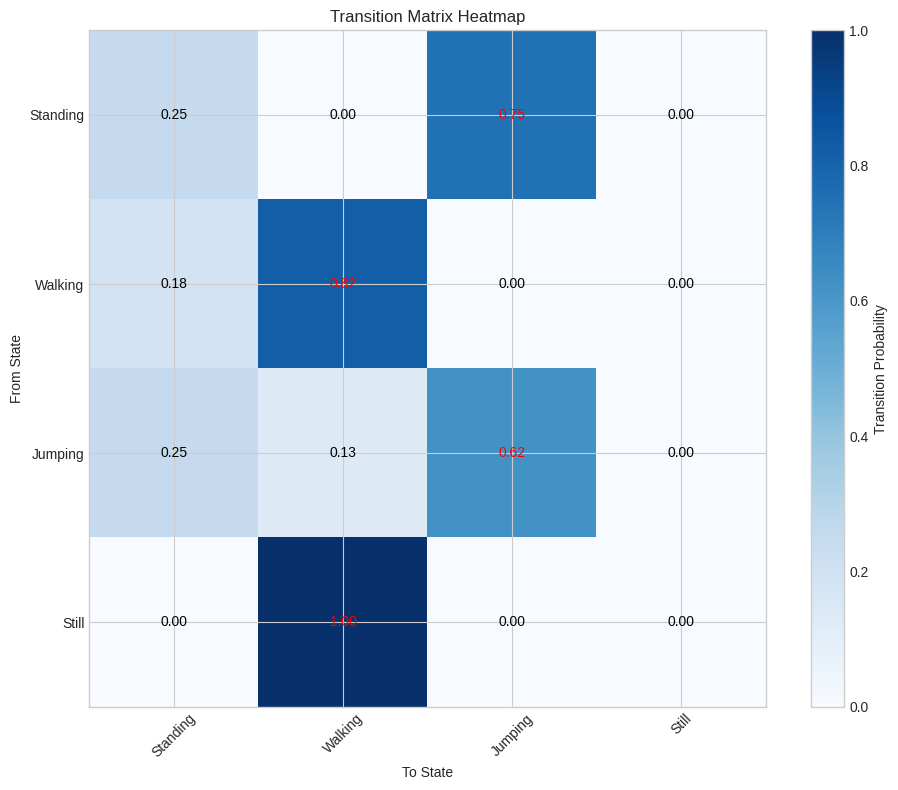


Transition Matrix (with labels):
  Stan→Stan: 0.250, Stan→Walk: 0.000, Stan→Jump: 0.750, Stan→Stil: 0.000
  Walk→Stan: 0.182, Walk→Walk: 0.818, Walk→Jump: 0.000, Walk→Stil: 0.000
  Jump→Stan: 0.250, Jump→Walk: 0.125, Jump→Jump: 0.625, Jump→Stil: 0.000
  Stil→Stan: 0.000, Stil→Walk: 1.000, Stil→Jump: 0.000, Stil→Stil: 0.000


In [ ]:
# ============================================
# CELL 17: VISUALIZE TRANSITION MATRIX
# ============================================

print("=" * 60)
print("VISUALIZING TRANSITION MATRIX")
print("=" * 60)

import matplotlib.pyplot as plt
import numpy as np

# Activity labels (4 states)
activity_labels = ['Standing', 'Walking', 'Jumping', 'Still']

# Load the trained model
import joblib
model = joblib.load('/content/hmm_model_4states.pkl')

# Create heatmap
plt.figure(figsize=(10, 8))
plt.imshow(model.transmat_, cmap='Blues', interpolation='nearest')
plt.colorbar(label='Transition Probability')
plt.xticks(range(4), activity_labels, rotation=45)
plt.yticks(range(4), activity_labels)
plt.title('Transition Matrix Heatmap')
plt.xlabel('To State')
plt.ylabel('From State')

# Add text annotations
for i in range(4):
    for j in range(4):
        plt.text(j, i, f'{model.transmat_[i, j]:.2f}',
                 ha='center', va='center',
                 color='red' if model.transmat_[i, j] > 0.5 else 'black')

plt.tight_layout()
plt.show()

print("\nTransition Matrix (with labels):")
for i, from_state in enumerate(activity_labels):
    row = []
    for j, to_state in enumerate(activity_labels):
        row.append(f"{from_state[:4]}→{to_state[:4]}: {model.transmat_[i, j]:.3f}")
    print("  " + ", ".join(row))

DECODING ACTIVITY SEQUENCE
Log probability: -240.36
Predicted state sequence length: 25

First 25 predictions:
  Window  1: Still
  Window  2: Walking
  Window  3: Walking
  Window  4: Walking
  Window  5: Standing
  Window  6: Jumping
  Window  7: Jumping
  Window  8: Jumping
  Window  9: Standing
  Window 10: Standing
  Window 11: Jumping
  Window 12: Jumping
  Window 13: Jumping
  Window 14: Walking
  Window 15: Walking
  Window 16: Walking
  Window 17: Walking
  Window 18: Walking
  Window 19: Walking
  Window 20: Walking
  Window 21: Walking
  Window 22: Standing
  Window 23: Jumping
  Window 24: Jumping
  Window 25: Standing

Activity distribution:
  Standing: 5 windows (20.0%)
  Walking: 11 windows (44.0%)
  Jumping: 8 windows (32.0%)
  Still: 1 windows (4.0%)


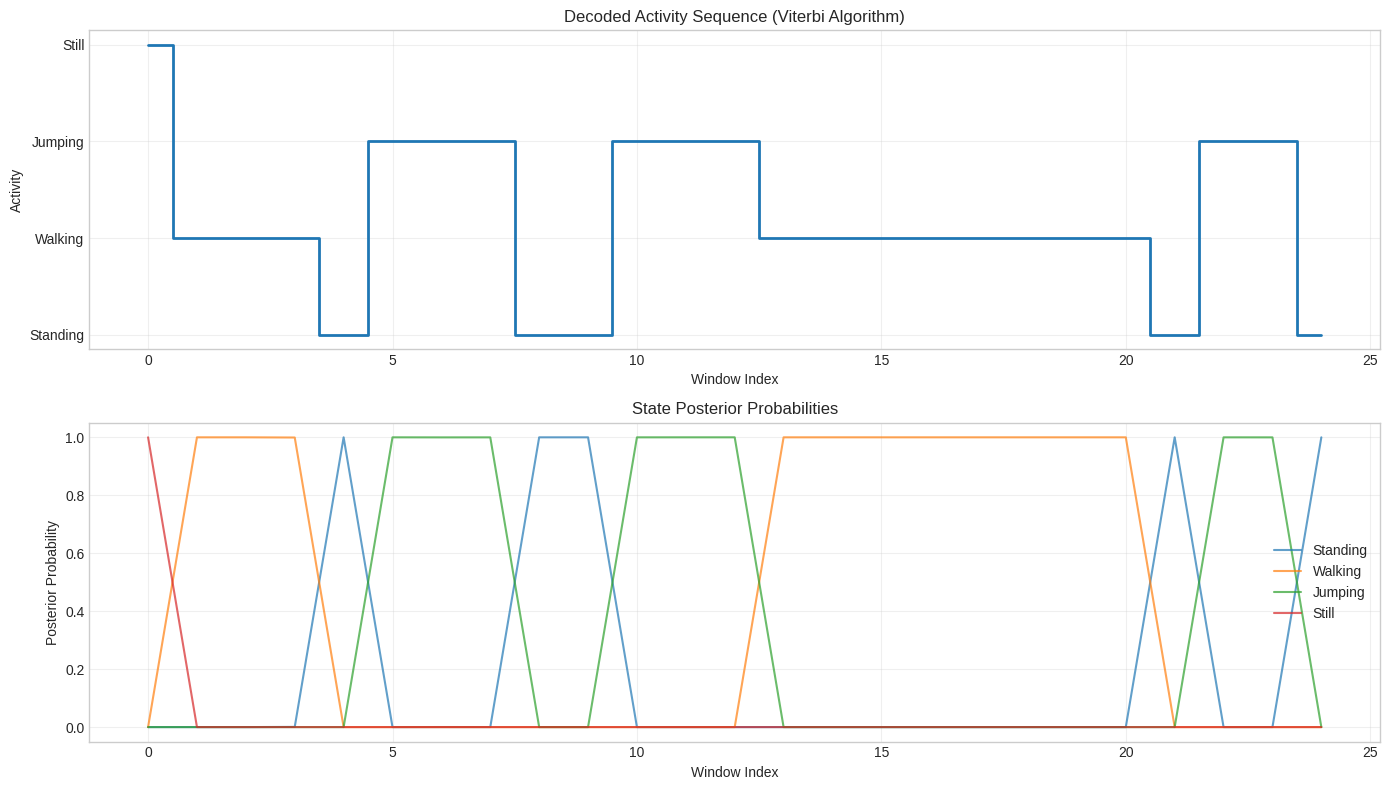

✓ Visualization complete!


In [ ]:
# ============================================
# CELL 18: DECODE AND PLOT ACTIVITY SEQUENCE
# ============================================

print("=" * 60)
print("DECODING ACTIVITY SEQUENCE")
print("=" * 60)

import numpy as np
import matplotlib.pyplot as plt

# Load data
features_normalized_df = pd.read_csv('/content/normalized_features.csv')
observation_sequences = features_normalized_df.values

# Decode the most likely sequence of activities
logprob, state_sequence = model.decode(observation_sequences, algorithm="viterbi")

# Map states to activities
state_to_activity = {i: activity_labels[i] for i in range(4)}
predicted_activities = [state_to_activity[state] for state in state_sequence]

print(f"Log probability: {logprob:.2f}")
print(f"Predicted state sequence length: {len(state_sequence)}")

print("\nFirst 25 predictions:")
for i in range(min(25, len(predicted_activities))):
    print(f"  Window {i+1:2d}: {predicted_activities[i]}")

# Count occurrences
print("\nActivity distribution:")
for i, activity in enumerate(activity_labels):
    count = np.sum(state_sequence == i)
    percentage = count / len(state_sequence) * 100
    print(f"  {activity}: {count} windows ({percentage:.1f}%)")

# Create figure
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

# Plot decoded states
ax1.step(range(len(state_sequence)), state_sequence, where='mid', linewidth=2)
ax1.set_yticks(range(4))
ax1.set_yticklabels(activity_labels)
ax1.set_xlabel('Window Index')
ax1.set_ylabel('Activity')
ax1.set_title('Decoded Activity Sequence (Viterbi Algorithm)')
ax1.grid(True, alpha=0.3)

# Plot state probabilities (posterior)
posterior = model.predict_proba(observation_sequences)
for i in range(4):
    ax2.plot(posterior[:, i], label=activity_labels[i], alpha=0.7)
ax2.set_xlabel('Window Index')
ax2.set_ylabel('Posterior Probability')
ax2.set_title('State Posterior Probabilities')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")

In [ ]:
# ============================================
# CELL 19: SAVE RESULTS
# ============================================

print("=" * 60)
print("SAVING RESULTS")
print("=" * 60)

import joblib
import numpy as np
import pandas as pd

# Save state sequence
np.save('/content/state_sequence.npy', state_sequence)
print("✓ State sequence saved to 'state_sequence.npy'")

# Save predictions as CSV
predictions_df = pd.DataFrame({
    'window_index': range(len(state_sequence)),
    'state': state_sequence,
    'activity': predicted_activities
})
predictions_df.to_csv('/content/predictions.csv', index=False)
print("✓ Predictions saved to 'predictions.csv'")

# Save posterior probabilities
posterior_df = pd.DataFrame(
    posterior,
    columns=activity_labels
)
posterior_df.to_csv('/content/posterior_probabilities.csv', index=False)
print("✓ Posterior probabilities saved to 'posterior_probabilities.csv'")

print("\n" + "=" * 60)
print("✅ HMM IMPLEMENTATION COMPLETE!")
print("=" * 60)
print("\nFiles saved:")
print("  • hmm_model_4states.pkl - Trained HMM model")
print("  • state_sequence.npy - Decoded state sequence")
print("  • predictions.csv - Predictions with activity labels")
print("  • posterior_probabilities.csv - State probabilities for each window")

SAVING RESULTS
✓ State sequence saved to 'state_sequence.npy'
✓ Predictions saved to 'predictions.csv'
✓ Posterior probabilities saved to 'posterior_probabilities.csv'

✅ HMM IMPLEMENTATION COMPLETE!

Files saved:
  • hmm_model_4states.pkl - Trained HMM model
  • state_sequence.npy - Decoded state sequence
  • predictions.csv - Predictions with activity labels
  • posterior_probabilities.csv - State probabilities for each window


In [ ]:
# ============================================
# CELL 20: MODEL STATISTICS SUMMARY
# ============================================

print("=" * 60)
print("MODEL STATISTICS SUMMARY")
print("=" * 60)

# Load the model
import joblib
model = joblib.load('/content/hmm_model_4states.pkl')

print("HMM Model Parameters:")
print("-" * 40)
print(f"Number of states: {model.n_components}")
print(f"Covariance type: {model.covariance_type}")
print(f"Number of features: {model.means_.shape[1]}")

print("\nStart Probabilities (π):")
for i, label in enumerate(activity_labels):
    print(f"  {label}: {model.startprob_[i]:.4f}")

print("\nTransition Matrix (A):")
for i, from_state in enumerate(activity_labels):
    print(f"  From {from_state}:")
    row = []
    for j, to_state in enumerate(activity_labels):
        row.append(f"  →{to_state[:4]}: {model.transmat_[i, j]:.3f}")
    print("".join(row))

print("\nEmission Means (μ) - First 5 features:")
feature_names = ['accel_mean', 'accel_std', 'accel_rms', 'gyro_mean', 'gyro_std']
for i, label in enumerate(activity_labels):
    print(f"  {label}: {model.means_[i][:5]}")

print("\n" + "=" * 60)
print("✅ Summary Complete!")

MODEL STATISTICS SUMMARY
HMM Model Parameters:
----------------------------------------
Number of states: 4
Covariance type: diag
Number of features: 14

Start Probabilities (π):
  Standing: 0.0000
  Walking: 0.0000
  Jumping: 0.0000
  Still: 1.0000

Transition Matrix (A):
  From Standing:
  →Stan: 0.250  →Walk: 0.000  →Jump: 0.750  →Stil: 0.000
  From Walking:
  →Stan: 0.182  →Walk: 0.818  →Jump: 0.000  →Stil: 0.000
  From Jumping:
  →Stan: 0.250  →Walk: 0.125  →Jump: 0.625  →Stil: 0.000
  From Still:
  →Stan: 0.000  →Walk: 1.000  →Jump: 0.000  →Stil: 0.000

Emission Means (μ) - First 5 features:
  Standing: [ 0.25158577 -0.0376211   0.85714226  0.22110357  0.19947378]
  Walking: [-0.21232668 -0.04914217 -0.04332437 -0.52029342  0.12455914]
  Jumping: [-0.35739419 -0.29907567 -0.01037745  0.97648063  0.24068883]
  Still: [ 3.93615271  3.12111475 -3.72723213 -3.19419208 -4.29305627]

✅ Summary Complete!


In [ ]:
# ============================================
# CELL: LOAD TEST DATA (FLEXIBLE)
# ============================================

print("=" * 60)
print("LOADING TEST DATA (FLEXIBLE)")
print("=" * 60)

import os
import pandas as pd
import zipfile
import glob

def load_test_sensor_data(file_path, sensor_name):
    """
    Load test sensor data from either ZIP or CSV file.
    """
    print(f"\nLoading {sensor_name} from: {os.path.basename(file_path)}")

    # Check if file exists
    if not os.path.exists(file_path):
        print(f"  ✗ File not found: {file_path}")
        return pd.DataFrame()

    # If it's a ZIP file
    if file_path.endswith('.zip'):
        print(f"  Detected ZIP file")

        # Create extraction folder
        extract_folder = f'/content/test_{sensor_name}_extracted'
        os.makedirs(extract_folder, exist_ok=True)

        # Extract ZIP
        try:
            with zipfile.ZipFile(file_path, 'r') as zip_ref:
                zip_ref.extractall(extract_folder)

            # Find all CSV files in the extracted folder
            csv_files = glob.glob(os.path.join(extract_folder, '*.csv'))
            print(f"  Found {len(csv_files)} CSV files in ZIP")

            # Load all CSV files
            all_dfs = []
            for csv_file in csv_files:
                print(f"    Reading: {os.path.basename(csv_file)}")
                df = load_single_test_csv(csv_file)
                if not df.empty:
                    all_dfs.append(df)
                    print(f"      Loaded {len(df)} samples")

            if all_dfs:
                combined_df = pd.concat(all_dfs, ignore_index=True)
                print(f"  Combined: {len(combined_df)} samples")
                return combined_df
            else:
                print(f"  ✗ No valid data found in ZIP")
                return pd.DataFrame()

        except Exception as e:
            print(f"  ✗ Error extracting ZIP: {e}")
            return pd.DataFrame()

    # If it's a CSV file
    elif file_path.endswith('.csv'):
        print(f"  Detected CSV file")
        return load_single_test_csv(file_path)

    else:
        print(f"  ✗ Unknown file type: {file_path}")
        return pd.DataFrame()

def load_single_test_csv(file_path):
    """
    Load a single CSV file with sensor data.
    """
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()
    except Exception as e:
        print(f"    ✗ Error reading file: {e}")
        return pd.DataFrame()

    data = []

    for line in lines:
        line = line.strip()
        if not line:
            continue

        try:
            parts = line.split(',')

            if len(parts) >= 3:
                timestamp_str = parts[1].strip('"')
                value_str = parts[2].strip('"')
                value = float(value_str)

                data.append({
                    'timestamp_raw': timestamp_str,
                    'value': value
                })
        except:
            continue

    df = pd.DataFrame(data)

    if not df.empty:
        df['time_seconds'] = df['timestamp_raw'].apply(parse_timestamp)
        df = df.dropna(subset=['time_seconds'])
        df = df.sort_values('time_seconds').reset_index(drop=True)

    return df

# Define file paths - update these to match your actual files
test_accel_zip = '/content/accelersensorlogtest (1).zip'  # Your accelerometer ZIP
test_gyro_zip = '/content/gyrosensorlogtest (1).zip'          # Your gyroscope ZIP

# Alternative: Check for individual CSV files
print("\n" + "-" * 40)
print("Checking for alternative file formats...")

# Check if there are individual CSV files
csv_files = glob.glob('/content/*.csv')
print(f"Found CSV files: {[os.path.basename(f) for f in csv_files]}")

# Try to find accelerometer and gyroscope files separately
accel_csv = None
gyro_csv = None

for f in csv_files:
    if 'accel' in f.lower():
        accel_csv = f
    if 'gyro' in f.lower():
        gyro_csv = f

print(f"\nIdentified:")
print(f"  Accelerometer file: {os.path.basename(accel_csv) if accel_csv else 'None found'}")
print(f"  Gyroscope file: {os.path.basename(gyro_csv) if gyro_csv else 'None found'}")

# Load data using the best available method
print("\n" + "=" * 60)
print("LOADING DATA...")
print("=" * 60)

# Load accelerometer data
if accel_csv:
    print("\nAttempting to load accelerometer from CSV...")
    test_accel_df = load_single_test_csv(accel_csv)
elif os.path.exists(test_accel_zip):
    print("\nAttempting to load accelerometer from ZIP...")
    test_accel_df = load_test_sensor_data(test_accel_zip, 'accel')
else:
    test_accel_df = pd.DataFrame()
    print("\n✗ No accelerometer test data found")

# Load gyroscope data
if gyro_csv:
    print("\nAttempting to load gyroscope from CSV...")
    test_gyro_df = load_single_test_csv(gyro_csv)
elif os.path.exists(test_gyro_zip):
    print("\nAttempting to load gyroscope from ZIP...")
    test_gyro_df = load_test_sensor_data(test_gyro_zip, 'gyro')
else:
    test_gyro_df = pd.DataFrame()
    print("\n✗ No gyroscope test data found")

# Summary
print("\n" + "=" * 60)
print("DATA LOADING SUMMARY")
print("=" * 60)
print(f"Accelerometer: {len(test_accel_df)} samples" if not test_accel_df.empty else "Accelerometer: No data loaded")
print(f"Gyroscope: {len(test_gyro_df)} samples" if not test_gyro_df.empty else "Gyroscope: No data loaded")

if not test_accel_df.empty and not test_gyro_df.empty:
    print("\n✅ Both accelerometer and gyroscope data loaded successfully!")
else:
    print("\n⚠️  Some data is missing. Please check your files.")
    print("Expected files:")
    print("  - test_accelersensorlog.zip OR a CSV file containing 'accel' in the name")
    print("  - test_gyrologs.zip OR a CSV file containing 'gyro' in the name")

LOADING TEST DATA (FLEXIBLE)

----------------------------------------
Checking for alternative file formats...
Found CSV files: ['predictions.csv', 'normalized_features.csv', 'processed_sensor_data.csv', 'posterior_probabilities.csv']

Identified:
  Accelerometer file: None found
  Gyroscope file: None found

LOADING DATA...

Attempting to load accelerometer from ZIP...

Loading accel from: accelersensorlogtest (1).zip
  Detected ZIP file
  Found 3 CSV files in ZIP
    Reading: accelersensorlogtest-1.csv
      Loaded 136 samples
    Reading: accelersensorlogtest.csv
      Loaded 136 samples
    Reading: accelersensorlogtest-2.csv
      Loaded 136 samples
  Combined: 408 samples

Attempting to load gyroscope from ZIP...

Loading gyro from: gyrosensorlogtest (1).zip
  Detected ZIP file
  Found 3 CSV files in ZIP
    Reading: gyrosensorlogtest-1.csv
      Loaded 136 samples
    Reading: gyrosensorlogtest.csv
      Loaded 136 samples
    Reading: gyrosensorlogtest-2.csv
      Loaded 136 s

PROCESSING AND EVALUATING TEST DATA
Test data loaded:
  Accelerometer: 408 samples
  Gyroscope: 408 samples

Reshaping test data...
  Accelerometer reshaped: 674 samples
  Gyroscope reshaped: 674 samples

Merged test data: 674 samples

Extracting features from test data...
Creating 12 windows...
  Extracted 12 windows
  Normalized features: (12, 14)

Decoding test data with HMM...

✓ Test data decoded!
  Log probability: -545.31
  Number of windows: 12

Test predictions (all windows):
  Window  1: Still
  Window  2: Walking
  Window  3: Standing
  Window  4: Standing
  Window  5: Standing
  Window  6: Standing
  Window  7: Standing
  Window  8: Standing
  Window  9: Standing
  Window 10: Standing
  Window 11: Standing
  Window 12: Standing

Test activity distribution:
  Standing: 10 windows (83.3%)
  Walking: 1 windows (8.3%)
  Jumping: 0 windows (0.0%)
  Still: 1 windows (8.3%)

✓ Test predictions saved to 'test_predictions_final.csv'


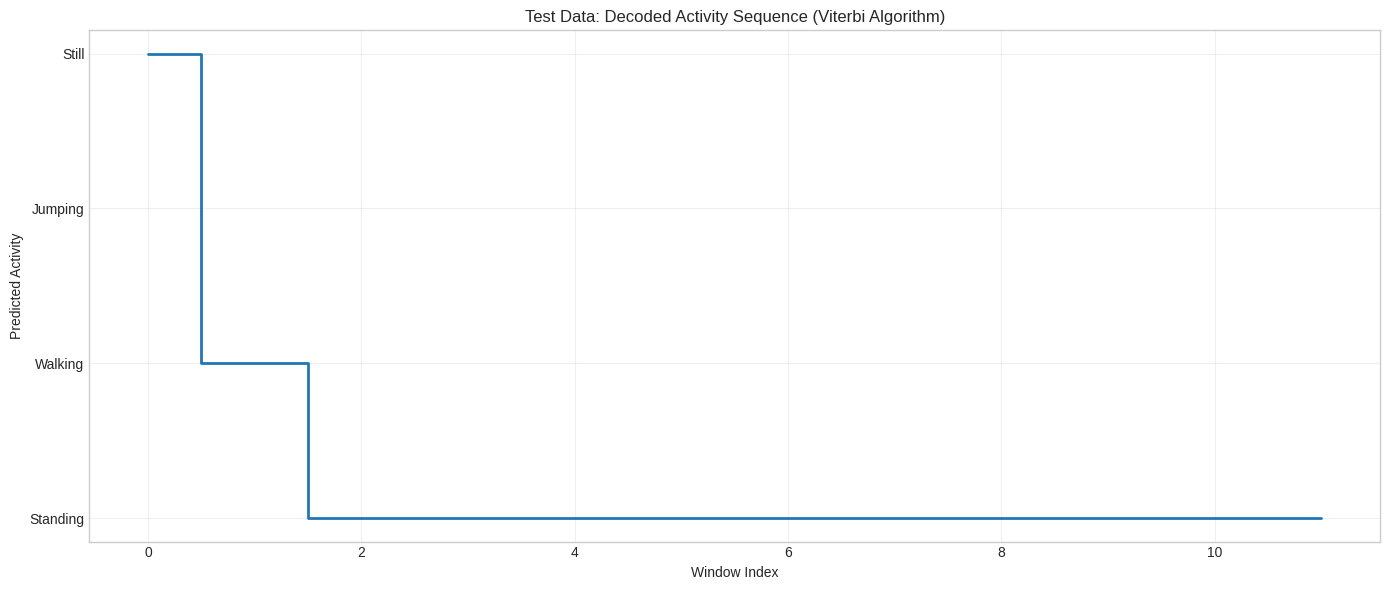


✅ Test data evaluation complete!


In [ ]:
# ============================================
# CELL: PROCESS AND EVALUATE TEST DATA
# ============================================

print("=" * 60)
print("PROCESSING AND EVALUATING TEST DATA")
print("=" * 60)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

# Load the trained model
model = joblib.load('/content/hmm_model_4states.pkl')

# Activity labels
activity_labels = ['Standing', 'Walking', 'Jumping', 'Still']
state_to_activity = {i: activity_labels[i] for i in range(4)}

print(f"Test data loaded:")
print(f"  Accelerometer: {len(test_accel_df)} samples")
print(f"  Gyroscope: {len(test_gyro_df)} samples")

# Reshape test data
print("\nReshaping test data...")
test_accel_reshaped = reshape_to_regular_timeseries(test_accel_df, SAMPLING_RATE)
test_gyro_reshaped = reshape_to_regular_timeseries(test_gyro_df, SAMPLING_RATE)

print(f"  Accelerometer reshaped: {len(test_accel_reshaped)} samples")
print(f"  Gyroscope reshaped: {len(test_gyro_reshaped)} samples")

# Merge test data
min_len_test = min(len(test_accel_reshaped), len(test_gyro_reshaped))
test_merged_df = pd.DataFrame({
    'timestamp': test_accel_reshaped['timestamp'][:min_len_test],
    'accel': test_accel_reshaped['value'][:min_len_test],
    'gyro': test_gyro_reshaped['value'][:min_len_test]
})

print(f"\nMerged test data: {len(test_merged_df)} samples")

# Extract features for test data
print("\nExtracting features from test data...")
test_features_df = create_windows_and_extract_features(test_merged_df, WINDOW_SIZE, STEP_SIZE)
print(f"  Extracted {len(test_features_df)} windows")

# Load the scaler and normalize
scaler = joblib.load('/content/feature_scaler.pkl')

# Handle any NaN values
test_features_clean = test_features_df.fillna(0).values
test_features_normalized = scaler.transform(test_features_clean)

print(f"  Normalized features: {test_features_normalized.shape}")

# Decode test data
print("\nDecoding test data with HMM...")
test_logprob, test_state_sequence = model.decode(test_features_normalized, algorithm="viterbi")

# Map to activities
test_predicted_activities = [state_to_activity[state] for state in test_state_sequence]

print(f"\n✓ Test data decoded!")
print(f"  Log probability: {test_logprob:.2f}")
print(f"  Number of windows: {len(test_state_sequence)}")

# Show predictions
print("\nTest predictions (all windows):")
for i, pred in enumerate(test_predicted_activities):
    print(f"  Window {i+1:2d}: {pred}")

# Count occurrences
print("\nTest activity distribution:")
for i, activity in enumerate(activity_labels):
    count = np.sum(test_state_sequence == i)
    percentage = count / len(test_state_sequence) * 100
    print(f"  {activity}: {count} windows ({percentage:.1f}%)")

# Save test predictions
test_predictions_df = pd.DataFrame({
    'window_index': range(len(test_state_sequence)),
    'state': test_state_sequence,
    'activity': test_predicted_activities
})
test_predictions_df.to_csv('/content/test_predictions_final.csv', index=False)
print("\n✓ Test predictions saved to 'test_predictions_final.csv'")

# Plot test predictions
fig, ax = plt.subplots(figsize=(14, 6))
ax.step(range(len(test_state_sequence)), test_state_sequence, where='mid', linewidth=2)
ax.set_yticks(range(4))
ax.set_yticklabels(activity_labels)
ax.set_xlabel('Window Index')
ax.set_ylabel('Predicted Activity')
ax.set_title('Test Data: Decoded Activity Sequence (Viterbi Algorithm)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Test data evaluation complete!")

GENERATING CONFUSION MATRIX
Calculating windows per test file...
  Samples per file: 136
  Window size: 100
  Step size: 50
  Windows per file: 1

Ground truth length: 4
Predictions length: 12
Using 4 samples for evaluation


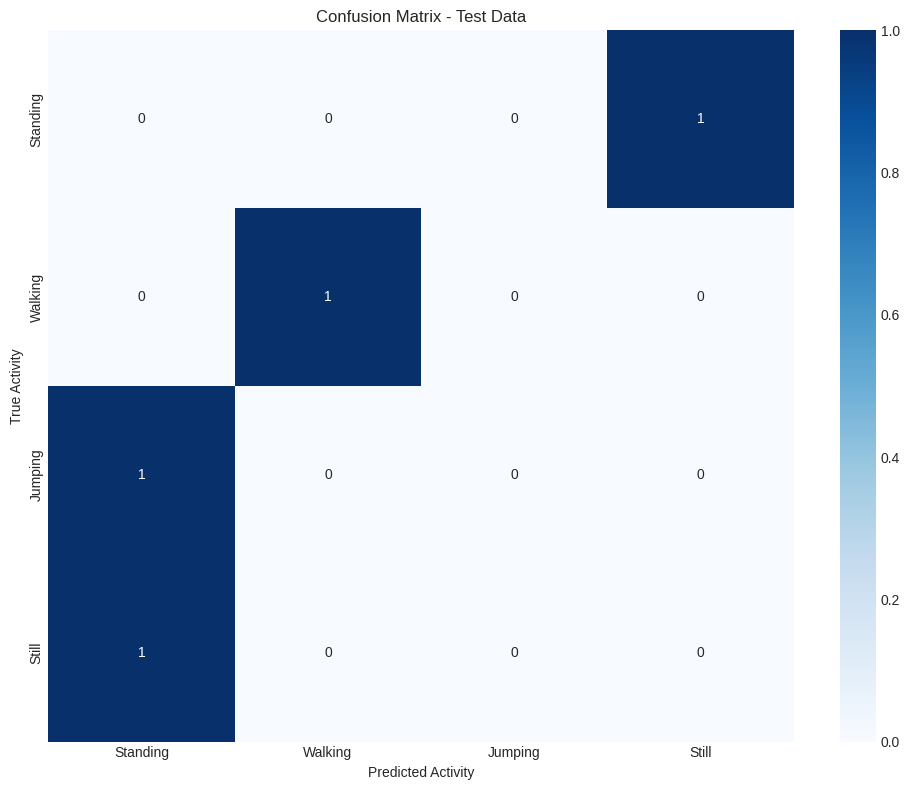


Classification Report:
              precision    recall  f1-score   support

    Standing       0.00      0.00      0.00         1
     Walking       0.00      0.00      0.00         1
     Jumping       0.00      0.00      0.00         1
       Still       1.00      1.00      1.00         1

    accuracy                           0.25         4
   macro avg       0.25      0.25      0.25         4
weighted avg       0.25      0.25      0.25         4


METRICS SUMMARY

Metrics Table:
Activity  Sensitivity  Specificity  Accuracy
Standing          0.0     0.333333      0.25
 Walking          1.0     1.000000      1.00
 Jumping          0.0     1.000000      0.75
   Still          0.0     0.666667      0.50

Overall Accuracy: 0.250 (25.0%)

✓ Metrics saved to 'test_metrics.csv'


In [ ]:
# ============================================
# CELL: GENERATE CONFUSION MATRIX
# ============================================

print("=" * 60)
print("GENERATING CONFUSION MATRIX")
print("=" * 60)

from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# GROUND TRUTH LABELS
# You need to specify which windows correspond to which activity
# Since you have 4 test files (standing, walking, jumping, still),
# and each file has 136 samples, we need to map windows to activities

# Calculate how many windows each file produced
# Each file has 136 samples, and with our window settings:
# Window size = 100 samples (2 sec at 50Hz)
# Step size = 50 samples (50% overlap)
# So windows per file = (136 - 100) / 50 + 1 = 1.72 -> 1 window per file? That's too few!

# Let's recalculate: With 136 samples, window_size=100, step_size=50
# Number of windows = (136 - 100) / 50 + 1 = 1 + 1 = 2 windows per file

print("Calculating windows per test file...")
samples_per_file = 136
windows_per_file = (samples_per_file - WINDOW_SIZE) // STEP_SIZE + 1
print(f"  Samples per file: {samples_per_file}")
print(f"  Window size: {WINDOW_SIZE}")
print(f"  Step size: {STEP_SIZE}")
print(f"  Windows per file: {windows_per_file}")

# Create ground truth labels
# Order: standing, walking, jumping, still
file_activities = ['Standing', 'Walking', 'Jumping', 'Still']
true_activities = []

for activity in file_activities:
    # Each file produces 'windows_per_file' windows
    true_activities.extend([activity] * windows_per_file)

# Make sure lengths match
print(f"\nGround truth length: {len(true_activities)}")
print(f"Predictions length: {len(test_predicted_activities)}")

# Trim to match (if there's a mismatch)
min_len = min(len(true_activities), len(test_predicted_activities))
true_activities = true_activities[:min_len]
predicted_activities = test_predicted_activities[:min_len]

print(f"Using {min_len} samples for evaluation")

# Create confusion matrix
label_map = {label: i for i, label in enumerate(activity_labels)}
true_numeric = [label_map[a] for a in true_activities]
pred_numeric = [label_map[p] for p in predicted_activities]

cm = confusion_matrix(true_numeric, pred_numeric)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=activity_labels,
            yticklabels=activity_labels)
plt.title('Confusion Matrix - Test Data')
plt.xlabel('Predicted Activity')
plt.ylabel('True Activity')
plt.tight_layout()
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(true_activities, predicted_activities, target_names=activity_labels))

# Calculate metrics
print("\n" + "=" * 60)
print("METRICS SUMMARY")
print("=" * 60)

metrics_data = []

for i, activity in enumerate(activity_labels):
    # Sensitivity (True Positive Rate)
    tp = cm[i, i]
    fn = cm[i, :].sum() - tp
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Specificity (True Negative Rate)
    tn = cm.sum() - cm[i, :].sum() - cm[:, i].sum() + tp
    fp = cm[:, i].sum() - tp
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0

    # Accuracy for this class
    accuracy = (tp + tn) / cm.sum() if cm.sum() > 0 else 0

    metrics_data.append({
        'Activity': activity,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'Accuracy': accuracy
    })

# Create metrics table
metrics_df = pd.DataFrame(metrics_data)
print("\nMetrics Table:")
print(metrics_df.to_string(index=False))

# Overall Accuracy
overall_accuracy = np.trace(cm) / cm.sum() if cm.sum() > 0 else 0
print(f"\nOverall Accuracy: {overall_accuracy:.3f} ({overall_accuracy*100:.1f}%)")

# Save metrics to CSV
metrics_df.to_csv('/content/test_metrics.csv', index=False)
print("\n✓ Metrics saved to 'test_metrics.csv'")

VISUALIZING TEST RESULTS


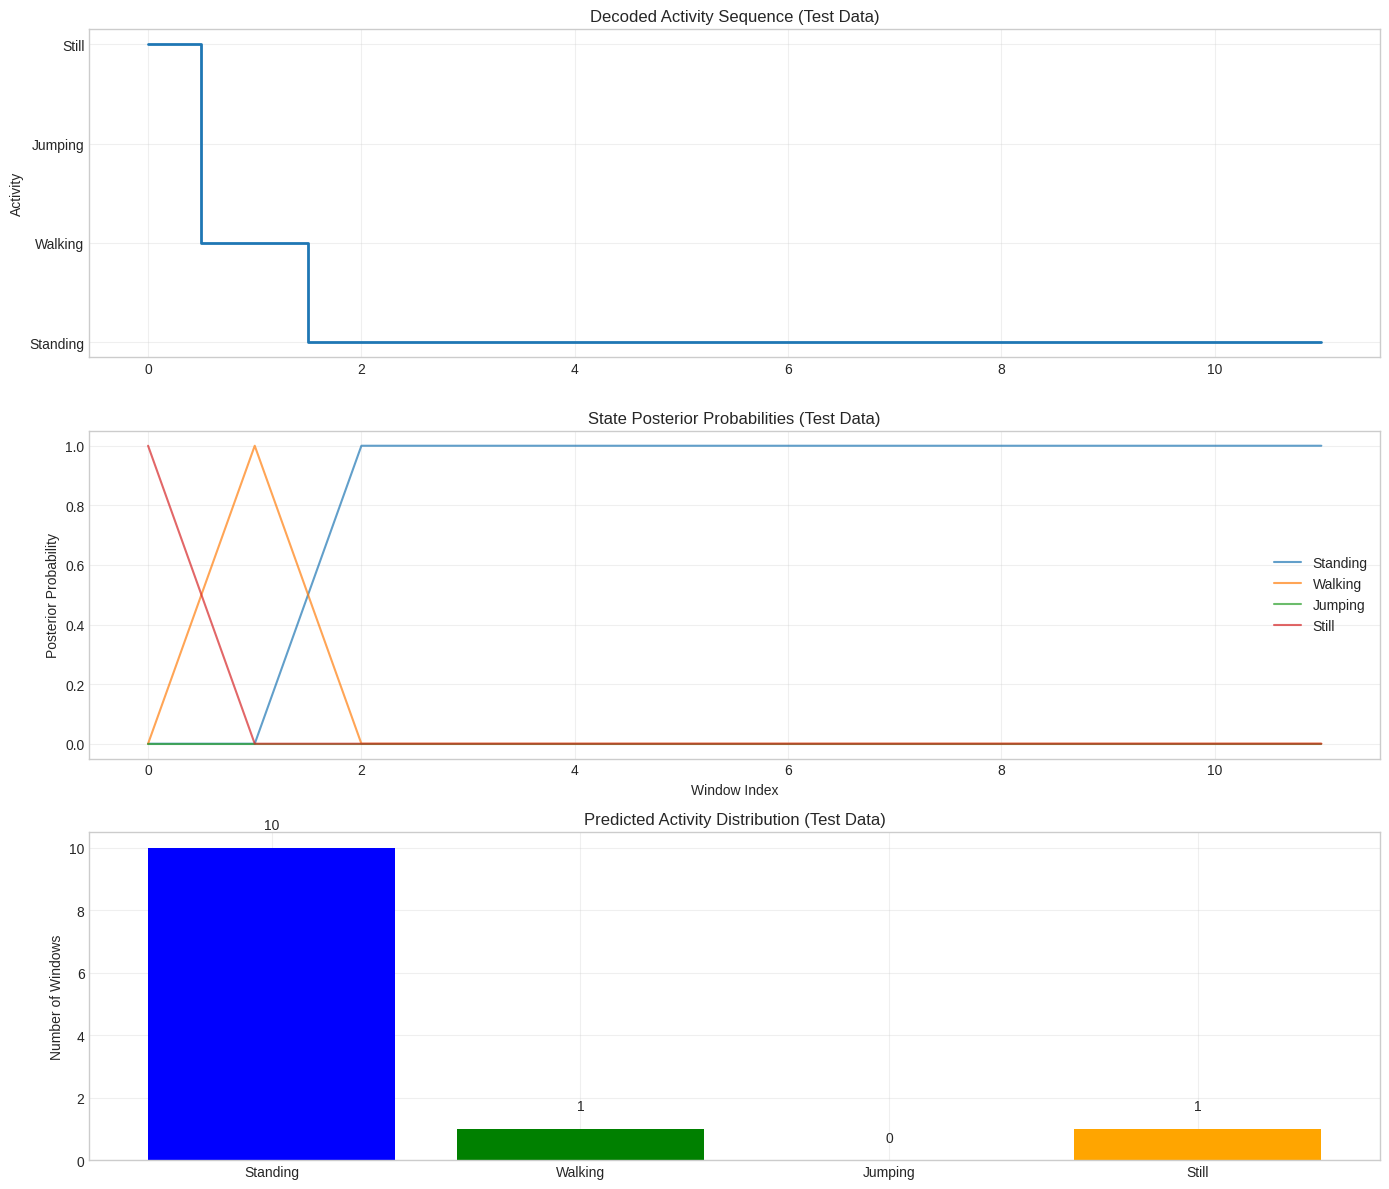

✓ Visualization complete!


In [ ]:
# ============================================
# CELL: VISUALIZE TEST RESULTS
# ============================================

print("=" * 60)
print("VISUALIZING TEST RESULTS")
print("=" * 60)

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# 1. Decoded sequence
axes[0].step(range(len(test_state_sequence)), test_state_sequence, where='mid', linewidth=2)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(activity_labels)
axes[0].set_ylabel('Activity')
axes[0].set_title('Decoded Activity Sequence (Test Data)')
axes[0].grid(True, alpha=0.3)

# 2. Posterior probabilities
posterior = model.predict_proba(test_features_normalized)
for i in range(4):
    axes[1].plot(posterior[:, i], label=activity_labels[i], alpha=0.7)
axes[1].set_xlabel('Window Index')
axes[1].set_ylabel('Posterior Probability')
axes[1].set_title('State Posterior Probabilities (Test Data)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Activity distribution
activity_counts = [np.sum(test_state_sequence == i) for i in range(4)]
bars = axes[2].bar(activity_labels, activity_counts, color=['blue', 'green', 'red', 'orange'])
axes[2].set_ylabel('Number of Windows')
axes[2].set_title('Predicted Activity Distribution (Test Data)')
axes[2].grid(True, alpha=0.3)

# Add value labels on bars
for bar, count in zip(bars, activity_counts):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("✓ Visualization complete!")

VISUALIZING EMISSION PROBABILITIES
Means shape: (4, 14)
Covars shape: (4, 14, 14)
Detected full covariance matrix. Extracting diagonal...
Variances shape: (4, 14)


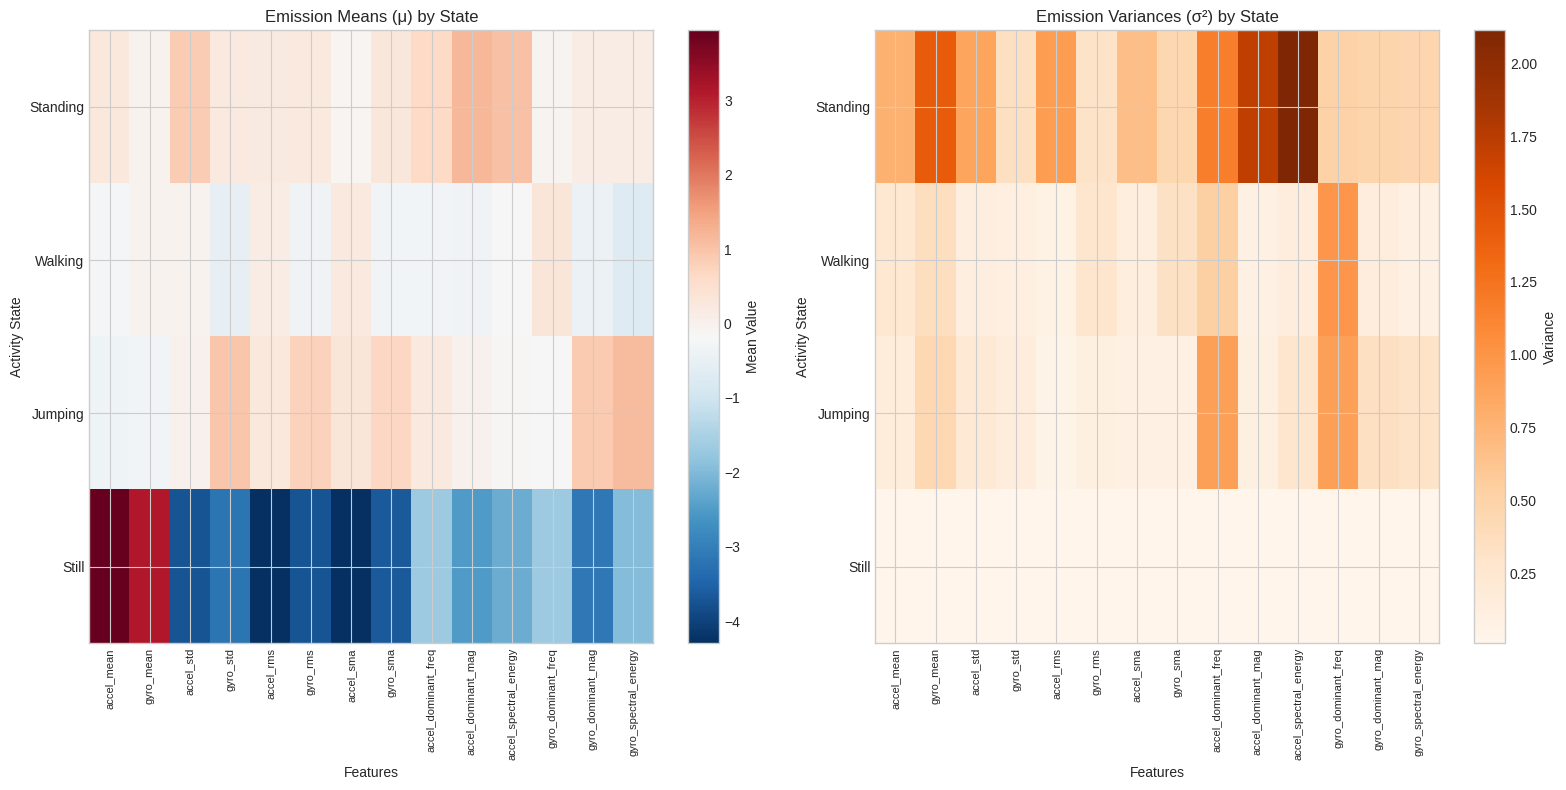

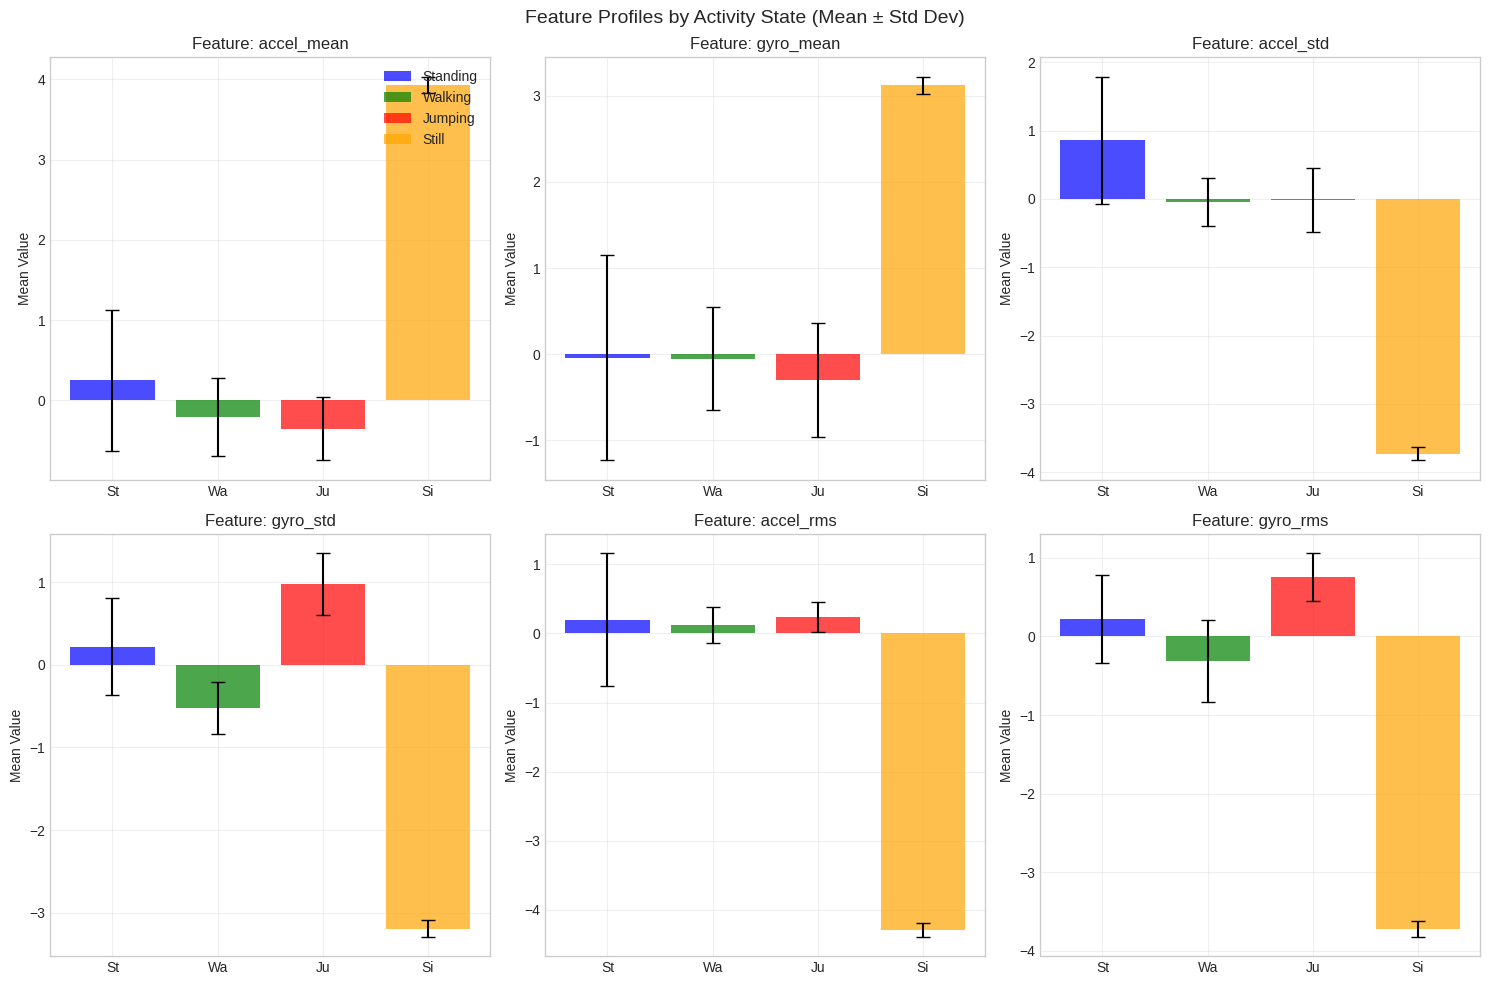

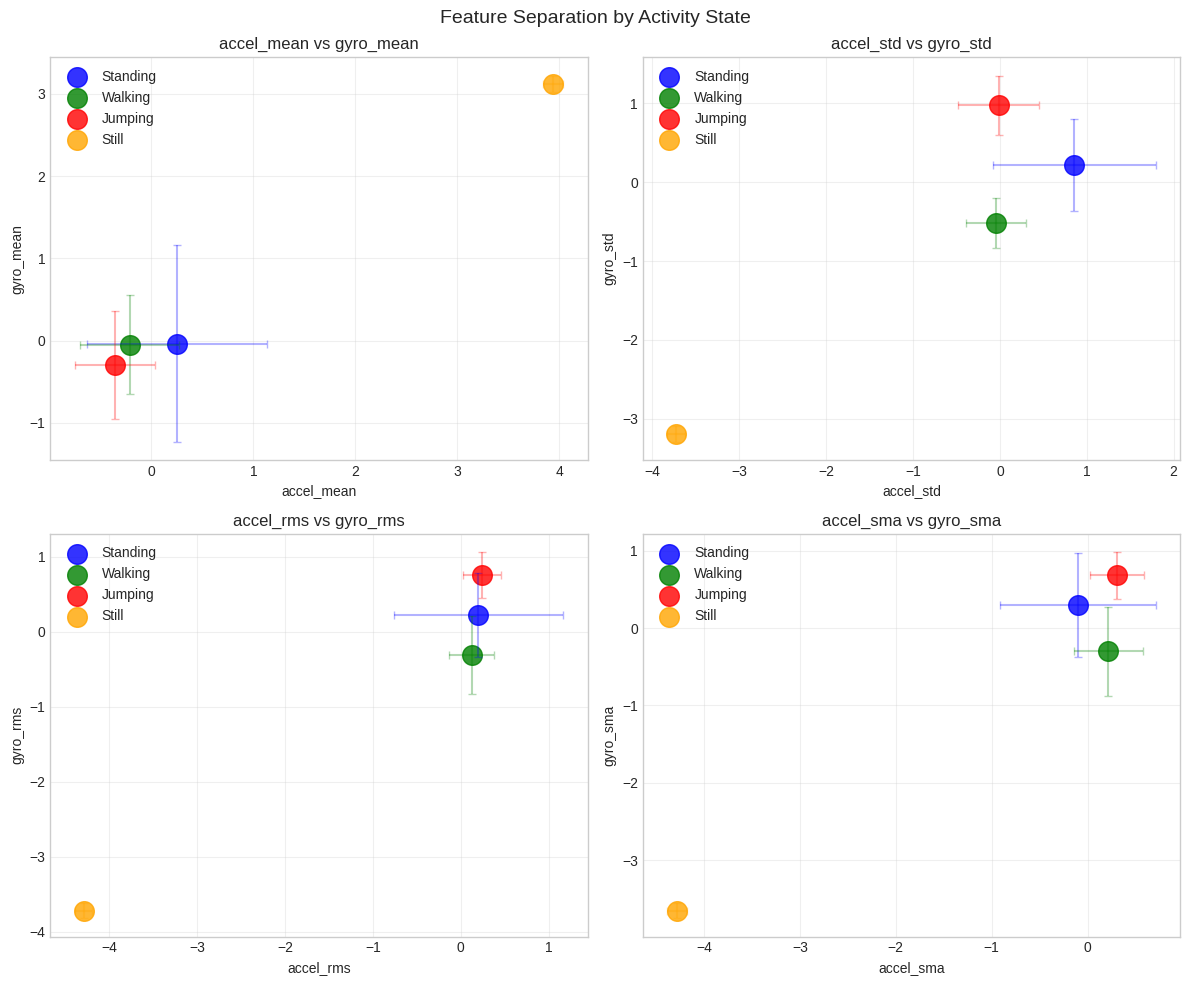


FEATURE SEPARATION ANALYSIS


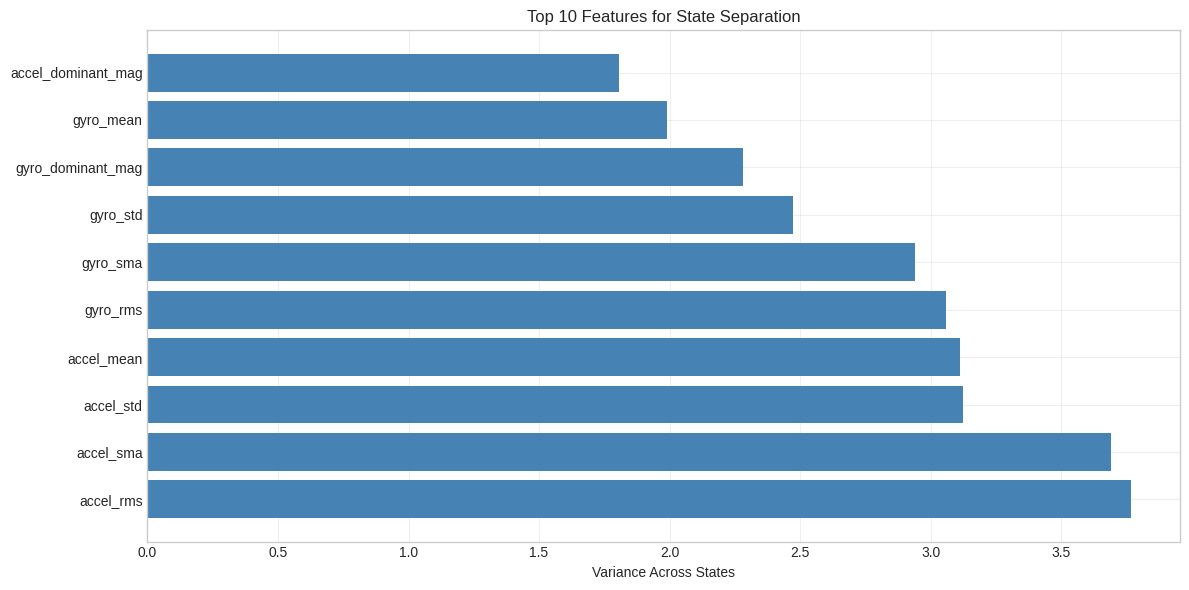

Top 5 features for separating activities:
  1. accel_rms: 3.7671
  2. accel_sma: 3.6902
  3. accel_std: 3.1229
  4. accel_mean: 3.1142
  5. gyro_rms: 3.0586

✓ Emission probabilities visualized!


In [ ]:
# ============================================
# CELL: VISUALIZE EMISSION PROBABILITIES (FIXED)
# ============================================

print("=" * 60)
print("VISUALIZING EMISSION PROBABILITIES")
print("=" * 60)

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import pandas as pd

# Load the trained model
model = joblib.load('/content/hmm_model_4states.pkl')

# Load feature names
features_df = pd.read_csv('/content/normalized_features.csv')
feature_names = features_df.columns.tolist()

# Activity labels
activity_labels = ['Standing', 'Walking', 'Jumping', 'Still']

# Get emission means and covariances
means = model.means_
covars = model.covars_

print(f"Means shape: {means.shape}")
print(f"Covars shape: {covars.shape}")

# Check if covars is 3D (full covariance) or 2D (diagonal)
if covars.ndim == 3:
    print("Detected full covariance matrix. Extracting diagonal...")
    # Extract diagonal variances (4 states x 14 features)
    variances = np.array([np.diag(covars[i]) for i in range(covars.shape[0])])
else:
    variances = covars

print(f"Variances shape: {variances.shape}")

# Figure 1: Heatmap of Emission Means
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Heatmap of means
im = axes[0].imshow(means, cmap='RdBu_r', aspect='auto')
axes[0].set_xticks(range(len(feature_names)))
axes[0].set_xticklabels(feature_names, rotation=90, fontsize=8)
axes[0].set_yticks(range(4))
axes[0].set_yticklabels(activity_labels)
axes[0].set_title('Emission Means (μ) by State')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Activity State')
plt.colorbar(im, ax=axes[0], label='Mean Value')

# Heatmap of variances (diagonal)
im2 = axes[1].imshow(variances, cmap='Oranges', aspect='auto')
axes[1].set_xticks(range(len(feature_names)))
axes[1].set_xticklabels(feature_names, rotation=90, fontsize=8)
axes[1].set_yticks(range(4))
axes[1].set_yticklabels(activity_labels)
axes[1].set_title('Emission Variances (σ²) by State')
axes[1].set_xlabel('Features')
axes[1].set_ylabel('Activity State')
plt.colorbar(im2, ax=axes[1], label='Variance')

plt.tight_layout()
plt.show()

# Figure 2: Feature profiles for each state (top 6 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

top_features = feature_names[:6]  # First 6 features

for i, feature in enumerate(top_features):
    idx = feature_names.index(feature)
    for state in range(4):
        axes[i].bar(state, means[state, idx],
                   label=activity_labels[state] if i == 0 else "",
                   color=['blue', 'green', 'red', 'orange'][state],
                   alpha=0.7)
        # Add error bar (standard deviation)
        std = np.sqrt(variances[state, idx])
        axes[i].errorbar(state, means[state, idx],
                        yerr=std,
                        color='black', capsize=5, fmt='none')

    axes[i].set_title(f'Feature: {feature}')
    axes[i].set_xticks(range(4))
    axes[i].set_xticklabels(['St', 'Wa', 'Ju', 'Si'])
    axes[i].set_ylabel('Mean Value')
    axes[i].grid(True, alpha=0.3)

axes[0].legend(loc='upper right')
plt.suptitle('Feature Profiles by Activity State (Mean ± Std Dev)', fontsize=14)
plt.tight_layout()
plt.show()

# Figure 3: Pairwise feature comparison for state separation
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

feature_pairs = [(0, 1), (2, 3), (4, 5), (6, 7)]  # Pair features

for i, (f1_idx, f2_idx) in enumerate(feature_pairs):
    if f1_idx < len(feature_names) and f2_idx < len(feature_names):
        f1_name = feature_names[f1_idx]
        f2_name = feature_names[f2_idx]

        for state in range(4):
            # Plot the mean as a point
            axes[i].scatter(means[state, f1_idx], means[state, f2_idx],
                           s=200, label=activity_labels[state],
                           color=['blue', 'green', 'red', 'orange'][state],
                           alpha=0.8)

            # Add error ellipse (2 std dev)
            std_f1 = np.sqrt(variances[state, f1_idx])
            std_f2 = np.sqrt(variances[state, f2_idx])

            axes[i].errorbar(means[state, f1_idx], means[state, f2_idx],
                            xerr=std_f1, yerr=std_f2,
                            color=['blue', 'green', 'red', 'orange'][state],
                            alpha=0.3, capsize=3)

        axes[i].set_xlabel(f1_name)
        axes[i].set_ylabel(f2_name)
        axes[i].set_title(f'{f1_name} vs {f2_name}')
        axes[i].grid(True, alpha=0.3)
        axes[i].legend(loc='best')

plt.suptitle('Feature Separation by Activity State', fontsize=14)
plt.tight_layout()
plt.show()

# Figure 4: Feature importance - Which features best separate states?
print("\n" + "=" * 60)
print("FEATURE SEPARATION ANALYSIS")
print("=" * 60)

# Calculate feature variance across states (higher = better separation)
feature_variance_across_states = np.var(means, axis=0)
feature_names_sorted = [feature_names[i] for i in np.argsort(feature_variance_across_states)[::-1]]
variances_sorted = np.sort(feature_variance_across_states)[::-1]

plt.figure(figsize=(12, 6))
bars = plt.barh(feature_names_sorted[:10], variances_sorted[:10], color='steelblue')
plt.xlabel('Variance Across States')
plt.title('Top 10 Features for State Separation')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Top 5 features for separating activities:")
for i in range(min(5, len(feature_names_sorted))):
    print(f"  {i+1}. {feature_names_sorted[i]}: {variances_sorted[i]:.4f}")

print("\n✓ Emission probabilities visualized!")

In [ ]:
# ============================================
# CELL: DOWNLOAD GITHUB FOLDER AS ZIP
# ============================================

# Create ZIP of the entire folder
!zip -r /content/HMM_Activity_Recognition.zip /content/github_upload/

# Download the ZIP
from google.colab import files
files.download('/content/HMM_Activity_Recognition.zip')

print("✓ ZIP file downloaded!")

	zip warning: name not matched: /content/github_upload/

zip error: Nothing to do! (try: zip -r /content/HMM_Activity_Recognition.zip . -i /content/github_upload/)


FileNotFoundError: Cannot find file: /content/HMM_Activity_Recognition.zip